# RNA-seq Analysis of Human Cancer Data from GEO

## Resources

This notebook utilizes a variety of tools and libraries to perform the RNA-seq analysis:

*   **Python Libraries**:
    *   `pandas`: For data manipulation and integration.
    *   `numpy`: For numerical operations.
    *   `rpy2`: To bridge Python with R, allowing the use of R packages.
    *   `scikit-learn`: Specifically for Principal Component Analysis (PCA).
    *   `matplotlib` and `seaborn`: For data visualization (Volcano Plots, PCA, Violin Plots).
    *   `gprofiler-official`: For functional enrichment analysis.

*   **R Packages (via `rpy2`)**:
    *   `BiocManager`: For installing Bioconductor packages.
    *   `limma`: For differential gene expression analysis, including `voom` transformation.
    *   `Biobase`: A dependency for `limma`.

*   **External Tools**:
    *   **SRA Toolkit**: Used for `esearch` and `efetch` commands to query NCBI databases (though data was ultimately provided as a `.tar` file in this specific run).
    *   **GEO Database (NCBI)**: Source for the RNA-seq dataset (`GSE50760`) and metadata.

*   **Environment**:
    *   **Google Colaboratory**: The platform used to run this notebook.

This notebook guides you through an RNA-seq analysis on a human cancer dataset, leveraging a pre-processed FPKM data archive. The pipeline covers the following key steps:

1.  **Data Acquisition & Extraction**: Rather than downloading raw sequencing data, we extract pre-compiled FPKM (Fragments Per Kilobase Million) expression files from a provided `.tar` archive.
2.  **Data Loading and Integration**: Individual FPKM files are read and combined into a comprehensive gene expression matrix, which is then merged with corresponding sample metadata from the Gene Expression Omnibus (GEO) database.
3.  **Data Preprocessing**: The FPKM data is prepared for differential expression analysis, including log2 transformation to stabilize variance and address issues with zero values.
4.  **Differential Gene Expression (DGE) Analysis**: We utilize the `limma` package in R (accessed via `rpy2`) with its `voom` function, which is well-suited for DGE analysis of count-like data such as FPKM values.
5.  **Visualization**: Key visualization techniques are employed to interpret the data, including Principal Component Analysis (PCA) to explore sample clustering, Volcano Plots to highlight differentially expressed genes, and Violin Plots for specific gene expression patterns.
6.  **Functional Enrichment Analysis**: Significantly differentially expressed genes are subjected to functional enrichment analysis using gProfiler to identify over-represented biological pathways, gene ontology terms, and other molecular characteristics.

## Step 1: Specify GEO Dataset and Set Up Environment

First, please provide the **GEO accession ID** of the human cancer dataset you wish to analyze (e.g., `GSE12345`). This ID will allow us to fetch the relevant metadata and sequencing data.

In [3]:
# Define the GEO accession ID
GEO_ACCESSION_ID = 'GSE50760'
print(f"Using GEO Accession ID: {GEO_ACCESSION_ID}")

Using GEO Accession ID: GSE50760


## Step 2 (Revised): Extract Raw Data

Since the SRA accessions couldn't be retrieved programmatically and you've directly provided a processed `.tar` file, we'll proceed by extracting its contents. This file likely contains the raw count data or other processed files for `GSE50760`.

In [4]:
# Define the path to the downloaded tar file
TAR_FILE = '/content/GSE50760_RAW.tar'

# Create a directory to extract the files into
EXTRACT_DIR = './GSE50760_RAW_data'
!mkdir -p {EXTRACT_DIR}

# Extract the tar file
print(f"Extracting {TAR_FILE} to {EXTRACT_DIR}...")
!tar -xvf {TAR_FILE} -C {EXTRACT_DIR}
print("Extraction complete.")

# List the contents of the extracted directory to see what we have
print(f"\nContents of {EXTRACT_DIR}:")
!ls -lh {EXTRACT_DIR}

Extracting /content/GSE50760_RAW.tar to ./GSE50760_RAW_data...
GSM1228184_AMC_2.1_FPKM.txt.gz
GSM1228185_AMC_3.1_FPKM.txt.gz
GSM1228186_AMC_5.1_FPKM.txt.gz
GSM1228187_AMC_6.1_FPKM.txt.gz
GSM1228188_AMC_7.1_FPKM.txt.gz
GSM1228189_AMC_8.1_FPKM.txt.gz
GSM1228190_AMC_9.1_FPKM.txt.gz
GSM1228191_AMC_10.1_FPKM.txt.gz
GSM1228192_AMC_12.1_FPKM.txt.gz
GSM1228193_AMC_13.1_FPKM.txt.gz
GSM1228194_AMC_17.1_FPKM.txt.gz
GSM1228195_AMC_18.1_FPKM.txt.gz
GSM1228196_AMC_19.1_FPKM.txt.gz
GSM1228197_AMC_20.1_FPKM.txt.gz
GSM1228198_AMC_21.1_FPKM.txt.gz
GSM1228199_AMC_22.1_FPKM.txt.gz
GSM1228200_AMC_23.1_FPKM.txt.gz
GSM1228201_AMC_24.1_FPKM.txt.gz
GSM1228202_AMC_2.2_FPKM.txt.gz
GSM1228203_AMC_3.2_FPKM.txt.gz
GSM1228204_AMC_5.2_FPKM.txt.gz
GSM1228205_AMC_6.2_FPKM.txt.gz
GSM1228206_AMC_7.2_FPKM.txt.gz
GSM1228207_AMC_8.2_FPKM.txt.gz
GSM1228208_AMC_9.2_FPKM.txt.gz
GSM1228209_AMC_10.2_FPKM.txt.gz
GSM1228210_AMC_12.2_FPKM.txt.gz
GSM1228211_AMC_13.2_FPKM.txt.gz
GSM1228212_AMC_17.2_FPKM.txt.gz
GSM1228213_AMC_18.2_FPK

## Step 3: Load Gene Expression Data

The extracted directory contains individual FPKM (Fragments Per Kilobase Million) `.txt.gz` files for each sample. We need to read these files and combine them into a single gene expression matrix. We'll use pandas to load and merge this data.

In [5]:
import pandas as pd
import os
import glob

print(f"Current working directory: {os.getcwd()}")
# Ensure EXTRACT_DIR is an absolute path to avoid any ambiguity
EXTRACT_DIR_ABS = os.path.abspath(EXTRACT_DIR)
print(f"Checking absolute directory: {EXTRACT_DIR_ABS}")

# List contents of EXTRACT_DIR to verify files are there
print("Contents of EXTRACT_DIR (using os.listdir) and endswith check:")
all_files_in_dir = []
sample_filename_for_debug = None
EXPECTED_SUFFIX = '_FPKM.txt.gz' # Corrected suffix here

try:
    for f_name_raw in os.listdir(EXTRACT_DIR_ABS):
        # Aggressively clean filename: remove null bytes and then strip whitespace
        f_name_cleaned = f_name_raw.replace('\x00', '').strip()
        full_path = os.path.join(EXTRACT_DIR_ABS, f_name_cleaned)
        all_files_in_dir.append(full_path)
        ends_with_check = f_name_cleaned.endswith(EXPECTED_SUFFIX)

        print(f"  Raw File: '{f_name_raw}' (len: {len(f_name_raw)}), Cleaned: '{f_name_cleaned}' (len: {len(f_name_cleaned)}), ends_with_{EXPECTED_SUFFIX.replace('.', '_')}: {ends_with_check}")
        if sample_filename_for_debug is None:
            sample_filename_for_debug = f_name_raw
except FileNotFoundError:
    print(f"Error: Directory {EXTRACT_DIR_ABS} not found.")

if sample_filename_for_debug:
    # Re-clean the sample filename for focused debug output
    cleaned_sample_filename = sample_filename_for_debug.replace('\x00', '').strip()
    print(f"\nDebugging sample filename: repr('{sample_filename_for_debug}') -> {repr(sample_filename_for_debug)}")
    print(f"  Cleaned sample filename repr: {repr(cleaned_sample_filename)}")
    print(f"Expected suffix: '{EXPECTED_SUFFIX}'")
    print(f"Is it present after cleaning?: {cleaned_sample_filename.endswith(EXPECTED_SUFFIX)}")
    if len(cleaned_sample_filename) >= len(EXPECTED_SUFFIX):
        actual_suffix_part = cleaned_sample_filename[-len(EXPECTED_SUFFIX):]
        print(f"  Expected suffix part repr: {repr(EXPECTED_SUFFIX)}")
        print(f"  Actual suffix part repr (from cleaned name): {repr(actual_suffix_part)}")
        print(f"  Suffixes are equal after cleaning: {actual_suffix_part == EXPECTED_SUFFIX}")

# Get a list of all FPKM files using glob
# Glob might also be affected by invisible characters, so we'll rely more on manual filtering now.
glob_pattern = os.path.join(EXTRACT_DIR_ABS, f'*{EXPECTED_SUFFIX}')
print(f"\nGlob pattern used: '{glob_pattern}'")
fpkm_files_glob = glob.glob(glob_pattern)

if not fpkm_files_glob:
    print(f"glob.glob found {len(fpkm_files_glob)} FPKM files with pattern '{glob_pattern}'. This is expected if invisible chars are present.")
    print("Attempting manual filtering with aggressive cleaning as fallback...")
    # Manually filter from all_files_in_dir, cleaning filenames before checking suffix
    fpkm_files = []
    for f_path_raw in os.listdir(EXTRACT_DIR_ABS):
        f_name_cleaned = f_path_raw.replace('\x00', '').strip()
        if f_name_cleaned.endswith(EXPECTED_SUFFIX):
            # Append the full path with the cleaned filename for consistency
            fpkm_files.append(os.path.join(EXTRACT_DIR_ABS, f_name_cleaned))

    if not fpkm_files:
        print("Manual filtering with aggressive cleaning also found no FPKM files. This is highly unusual.")
    else:
        print(f"Manual filtering with aggressive cleaning succeeded, found {len(fpkm_files)} FPKM files.")
else:
    print(f"Glob found {len(fpkm_files_glob)} FPKM files.")
    fpkm_files = fpkm_files_glob


if not fpkm_files:
    print("FATAL: No FPKM data could be found or loaded.")
else:
    print(f"\nFound {len(fpkm_files)} FPKM files. Loading data...")

    # Initialize an empty list to store individual dataframes
    all_fpkm_dfs = []

    for file_path in fpkm_files:
        # Ensure we are cleaning the basename when extracting sample_id as well
        # os.path.basename(file_path) will already be clean if coming from our fpkm_files list
        sample_id = os.path.basename(file_path).replace(EXPECTED_SUFFIX, '')

        # Read the FPKM file. Assuming it's a tab-separated file with gene names in the first column
        # and FPKM values in the second (or similar simple structure).
        try:
            # Read only the first few lines to infer structure
            # The 'compression' parameter handles .gz files automatically
            df_sample = pd.read_csv(file_path, sep='\t', header=None, names=['GeneID', sample_id], index_col=0, compression='gzip')

            # Print first few lines after successful loading for verification
            print(f"\nSuccessfully loaded {sample_id}. First 5 rows:")
            print(df_sample.head())

            all_fpkm_dfs.append(df_sample)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

    if all_fpkm_dfs:
        # Concatenate all dataframes into a single expression matrix
        expression_df = pd.concat(all_fpkm_dfs, axis=1)

        # Display the shape and first few rows of the combined dataframe
        print(f"\nCombined expression matrix shape: {expression_df.shape}")
        print("First 5 rows of the expression matrix:")
        print(expression_df.head())

        # Store the expression data for further steps
        GENE_EXPRESSION_DF = expression_df
    else:
        print("No FPKM data could be combined into a DataFrame.")

Current working directory: /content
Checking absolute directory: /content/GSE50760_RAW_data
Contents of EXTRACT_DIR (using os.listdir) and endswith check:
  Raw File: 'GSM1228206_AMC_7.2_FPKM.txt.gz' (len: 30), Cleaned: 'GSM1228206_AMC_7.2_FPKM.txt.gz' (len: 30), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228234_AMC_21.3_FPKM.txt.gz' (len: 31), Cleaned: 'GSM1228234_AMC_21.3_FPKM.txt.gz' (len: 31), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228217_AMC_22.2_FPKM.txt.gz' (len: 31), Cleaned: 'GSM1228217_AMC_22.2_FPKM.txt.gz' (len: 31), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228207_AMC_8.2_FPKM.txt.gz' (len: 30), Cleaned: 'GSM1228207_AMC_8.2_FPKM.txt.gz' (len: 30), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228226_AMC_9.3_FPKM.txt.gz' (len: 30), Cleaned: 'GSM1228226_AMC_9.3_FPKM.txt.gz' (len: 30), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228228_AMC_12.3_FPKM.txt.gz' (len: 31), Cleaned: 'GSM1228228_AMC_12.3_FPKM.txt.gz' (len: 31), ends_with__FPKM_txt_gz: True
  Raw File:

## Step 4: Load Sample Metadata

Now that we have the gene expression data, we need to load the corresponding sample metadata from GEO. This metadata contains critical information about each sample, such as experimental group, tissue type, or treatment conditions, which is essential for differential expression analysis.

In [6]:
import pandas as pd
import os
import gzip

# 1. Download the Series Matrix file directly from NCBI FTP
matrix_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/matrix/GSE50760_series_matrix.txt.gz"
!wget -q {matrix_url} -O GSE50760_series_matrix.txt.gz

# 2. Parse the metadata lines (lines starting with !Sample_)
metadata_dict = {}
with gzip.open("GSE50760_series_matrix.txt.gz", "rt") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            metadata_dict["sample_title"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):
            metadata_dict["gsm_id"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_characteristics_ch1"):
            # GEO often has multiple characteristics lines; let's capture them dynamically
            key = f"characteristics_{len([k for k in metadata_dict if 'characteristics' in k])}"
            metadata_dict[key] = line.strip().split("\t")[1:]
        elif line.startswith("!series_matrix_table_begin"):
            # Stop reading once the massive expression table starts
            break

# 3. Build the Metadata DataFrame
SAMPLE_METADATA_DF = pd.DataFrame(metadata_dict)

# Clean up column names and string formatting neatly
SAMPLE_METADATA_DF.columns = [col.lower().replace(" ", "_") for col in SAMPLE_METADATA_DF.columns]

print(f"Successfully loaded metadata for {len(SAMPLE_METADATA_DF)} samples!")
display(SAMPLE_METADATA_DF.head())

Successfully loaded metadata for 54 samples!


,sample_title,gsm_id,characteristics_0,characteristics_1
0,"""primary colorectal cancer AMC_2-1""","""GSM1228184""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
1,"""primary colorectal cancer AMC_3-1""","""GSM1228185""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
2,"""primary colorectal cancer AMC_5-1""","""GSM1228186""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
3,"""primary colorectal cancer AMC_6-1""","""GSM1228187""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
4,"""primary colorectal cancer AMC_7-1""","""GSM1228188""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""


## Step 5: Data Integration and Preprocessing

With both the gene expression data (`GENE_EXPRESSION_DF`) and the sample metadata (`SAMPLE_METADATA_DF`) loaded, we need to integrate these two datasets. This involves ensuring that the sample identifiers are consistent across both tables and then merging them so that each gene expression column is associated with its correct sample characteristics.

We will also perform initial data cleaning and preparation, such as ensuring data types are correct and handling any obvious discrepancies.

In [7]:
import numpy as np
import re

# Transpose GENE_EXPRESSION_DF so samples are rows and genes are columns
# This makes it easier to merge with metadata where each row is a sample.

# Drop the row with 'genes' in the index if it exists, then transpose.
# The 'genes' row contains metadata about the FPKM files themselves, not gene expression.
if 'genes' in GENE_EXPRESSION_DF.index:
    expression_t = GENE_EXPRESSION_DF.drop(index='genes').T
else:
    expression_t = GENE_EXPRESSION_DF.T

# Ensure the index (sample IDs) of the transposed expression data are strings
expression_t.index = expression_t.index.astype(str)

# PROBLEM: The sample IDs in expression_t.index are like 'GSM1228213_AMC_18.2'
# while metadata 'gsm_id_cleaned' are like 'GSM1228184'.
# We need to extract only the 'GSM' part from the expression_t index.

# Extract base GSM ID from expression_t index (e.g., 'GSM1228213_AMC_18.2' -> 'GSM1228213')
def extract_gsm_id(sample_full_id):
    match = re.match(r'(GSM\d+)', sample_full_id)
    if match:
        return match.group(1)
    return None

expression_t['gsm_id_extracted'] = [extract_gsm_id(idx) for idx in expression_t.index]
expression_t = expression_t.set_index('gsm_id_extracted')
# Drop the temporary column and set the index. Handle potential None if extraction fails for some.
expression_t = expression_t[expression_t.index.notna()]

# Clean sample IDs in metadata_df to match expression_t index
# The gsm_id in SAMPLE_METADATA_DF might have quotes or leading/trailing spaces
SAMPLE_METADATA_DF['gsm_id_cleaned'] = SAMPLE_METADATA_DF['gsm_id'].str.replace('"', '').str.strip()

# Align sample IDs by finding common IDs between expression data and metadata
common_sample_ids = list(set(expression_t.index) & set(SAMPLE_METADATA_DF['gsm_id_cleaned']))

print(f"Number of samples in expression data: {expression_t.shape[0]}")
print(f"Number of samples in metadata: {SAMPLE_METADATA_DF.shape[0]}")
print(f"Number of common samples: {len(common_sample_ids)}")

# Filter both dataframes to include only common samples
# Ensure the order of samples is consistent for merging by using .loc and sorting
expression_filtered = expression_t.loc[common_sample_ids].sort_index()
metadata_filtered = SAMPLE_METADATA_DF[SAMPLE_METADATA_DF['gsm_id_cleaned'].isin(common_sample_ids)]

# Set 'gsm_id_cleaned' as index for metadata for easy merging
metadata_filtered = metadata_filtered.set_index('gsm_id_cleaned').sort_index()

# Merge the expression data with the metadata
# The `axis=1` means merging columns, matching on index (sample IDs)
MERGED_DATA_DF = pd.merge(expression_filtered, metadata_filtered, left_index=True, right_index=True)

print(f"\nShape of merged dataset: {MERGED_DATA_DF.shape}")
print("First 5 rows of merged dataset (expression values and metadata):")
display(MERGED_DATA_DF.head())

Number of samples in expression data: 54
Number of samples in metadata: 54
Number of common samples: 54

Shape of merged dataset: (54, 23509)
First 5 rows of merged dataset (expression values and metadata):


,A1BG,A1BG-AS1,A1CF,A2LD1,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AA06,...,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_title,gsm_id,characteristics_0,characteristics_1
gsm_id_extracted,,,,,,,,,,,,,,,,,,,,,
GSM1228184,0.241109,0.0281731,16.257,1.56614,33.1469,0,0,0.70743,0,0,...,5.88682,0.0537722,3.4685,27.7184,7.25732,6.29149,"""primary colorectal cancer AMC_2-1""","""GSM1228184""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228185,0.413634,0.0216056,12.4223,4.62522,46.8375,0,0.0296773,1.015,0,0,...,6.49676,0,3.40096,38.484,7.3298,8.53705,"""primary colorectal cancer AMC_3-1""","""GSM1228185""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228186,0.773777,0.149216,4.63792,3.55649,114.636,0,0,3.55672,0,0,...,4.93464,0.0110013,3.58314,28.372,13.0043,5.18621,"""primary colorectal cancer AMC_5-1""","""GSM1228186""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228187,0.290182,0.0540382,4.21296,6.13582,37.3062,0.00562125,0,3.07267,0,0,...,4.16064,0.0167459,3.1634,96.1591,4.25974,6.13764,"""primary colorectal cancer AMC_6-1""","""GSM1228187""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228188,0.508287,0.0835401,5.01399,6.76977,22.5658,0,0,1.03725,0,0,...,5.27769,0.0331415,3.63845,60.8978,5.33932,5.98535,"""primary colorectal cancer AMC_7-1""","""GSM1228188""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""


## Step 6: Define Comparison Groups for Differential Gene Expression Analysis

To perform differential gene expression analysis, we need to define our experimental groups. Based on the user's request, we will compare 'liver metastasis' samples against 'primary colorectal cancer' samples. We need to identify the appropriate column in the `SAMPLE_METADATA_DF` (or `MERGED_DATA_DF`) that contains this grouping information and extract the relevant labels.

In [8]:
# Inspect the unique values in relevant metadata columns to identify comparison groups
print("Unique values in 'sample_title' column:")
display(SAMPLE_METADATA_DF['sample_title'].unique())

print("\nUnique values in 'characteristics_0' column:")
display(SAMPLE_METADATA_DF['characteristics_0'].unique())

print("\nUnique values in 'characteristics_1' column:")
display(SAMPLE_METADATA_DF['characteristics_1'].unique())

Unique values in 'sample_title' column:


array(['"primary colorectal cancer AMC_2-1"',
       '"primary colorectal cancer AMC_3-1"',
       '"primary colorectal cancer AMC_5-1"',
       '"primary colorectal cancer AMC_6-1"',
       '"primary colorectal cancer AMC_7-1"',
       '"primary colorectal cancer AMC_8-1"',
       '"primary colorectal cancer AMC_9-1"',
       '"primary colorectal cancer AMC_10-1"',
       '"primary colorectal cancer AMC_12-1"',
       '"primary colorectal cancer AMC_13-1"',
       '"primary colorectal cancer AMC_17-1"',
       '"primary colorectal cancer AMC_18-1"',
       '"primary colorectal cancer AMC_19-1"',
       '"primary colorectal cancer AMC_20-1"',
       '"primary colorectal cancer AMC_21-1"',
       '"primary colorectal cancer AMC_22-1"',
       '"primary colorectal cancer AMC_23-1"',
       '"primary colorectal cancer AMC_24-1"', '"normal colon AMC_2-2"',
       '"normal colon AMC_3-2"', '"normal colon AMC_5-2"',
       '"normal colon AMC_6-2"', '"normal colon AMC_7-2"',
       '"normal c


Unique values in 'characteristics_0' column:


array(['"tissue: primary colorectal cancer"',
       '"tissue: normal-looking surrounding colonic epithelium"',
       '"tissue: metastatic colorectal cancer to the liver"'],
      dtype=object)


Unique values in 'characteristics_1' column:


array(['"ajcc stage: Stage IV"'], dtype=object)

### Define Comparison Groups

Based on the inspection, the `characteristics_0` column in our `SAMPLE_METADATA_DF` (and thus `MERGED_DATA_DF`) contains the relevant information to distinguish 'primary colorectal cancer' and 'metastatic colorectal cancer to the liver'.

We will define our two groups:
1.  **Control Group**: '"tissue: primary colorectal cancer"'
2.  **Treatment Group**: '"tissue: metastatic colorectal cancer to the liver"'

We also need to filter out any 'normal-looking surrounding colonic epithelium' samples if they are present in our merged dataset, as they are not part of this specific comparison.

In [9]:
import numpy as np
import re
import pandas as pd

# Define the column and specific values for the comparison
GROUP_COLUMN = 'characteristics_0'
PRIMARY_CANCER_LABEL = '"tissue: primary colorectal cancer"'
METASTASIS_LABEL = '"tissue: metastatic colorectal cancer to the liver"'

# Filter MERGED_DATA_DF to include only the samples for our comparison
comparison_df = MERGED_DATA_DF[
    (MERGED_DATA_DF[GROUP_COLUMN] == PRIMARY_CANCER_LABEL) |
    (MERGED_DATA_DF[GROUP_COLUMN] == METASTASIS_LABEL)
].copy()

print(f"Shape of data for comparison: {comparison_df.shape}")

# Identify gene columns based on position (assuming they come before 'sample_title')
# The gene expression columns are the first N columns, where N is the index of the first metadata column.
# Assuming 'sample_title' is the first metadata column added after all gene columns.
num_gene_cols = MERGED_DATA_DF.columns.get_loc('sample_title')
gene_columns_to_process = comparison_df.columns[:num_gene_cols]

# Apply pd.to_numeric to the entire DataFrame slice for gene columns
# This approach is generally more robust as it operates on a DataFrame context.
# First, convert the entire gene expression part to string representation to handle
# potential misinterpretation of gene symbols (e.g., '01-Mar' as a date).
gene_expression_slice_str = comparison_df[gene_columns_to_process].astype(str)

# Then, apply pd.to_numeric to this string DataFrame. Each element will be converted.
# If any conversion fails, it becomes NaN.
numeric_gene_expression_slice = gene_expression_slice_str.apply(pd.to_numeric, errors='coerce')

# Fill NaN values (resulting from 'coerce' errors) with 0
numeric_gene_expression_slice = numeric_gene_expression_slice.fillna(0)

# Assign the converted numeric slice back to comparison_df
# Use .values to ensure assignment by position/shape, bypassing strict column name alignment checks.
comparison_df[gene_columns_to_process] = numeric_gene_expression_slice.values

# Prepare the 'counts' matrix and 'colData' (metadata for DGE analysis)

# 1. Extract the gene expression matrix (numeric columns)
gene_expression_cols = comparison_df.select_dtypes(include=np.number).columns
counts_df = comparison_df[gene_expression_cols].copy()

# Ensure gene identifiers (columns of counts_df) are unique
# This is crucial for rpy2 conversion later to preserve gene names as row names.
if counts_df.columns.duplicated().any():
    print("Warning: Duplicate gene identifiers found in counts_df columns. Making them unique.")
    cols = pd.Series(counts_df.columns)
    for dup in cols[cols.duplicated()].unique():
        # Get all indices where this duplicate occurs
        dup_indices = cols[cols == dup].index.values.tolist()
        # Assign new unique names with a suffix (e.g., GeneName.1, GeneName.2)
        cols[dup_indices] = [f"{dup}.{i+1}" for i in range(len(dup_indices))]
    counts_df.columns = cols

# 2. Extract the metadata (non-numeric columns).
# This will include 'sample_title', 'gsm_id', and 'characteristics_X' columns.
metadata_cols = comparison_df.select_dtypes(exclude=np.number).columns
col_data = comparison_df[metadata_cols].copy()

# Ensure the index for col_data is consistent with counts_df (which it will be if sliced from comparison_df)
col_data.index = comparison_df.index
col_data.index.name = 'gsm_id_cleaned' # Explicitly name the index

# Ensure the col_data has the comparison column defined as category, with reference level
col_data[GROUP_COLUMN] = col_data[GROUP_COLUMN].astype('category')
col_data[GROUP_COLUMN] = col_data[GROUP_COLUMN].cat.reorder_categories([PRIMARY_CANCER_LABEL, METASTASIS_LABEL])

# Check if the indices match between counts_df and col_data
if not counts_df.index.equals(col_data.index):
    print("Error: Indices of counts_df and col_data do not match after filtering!")
    # Re-align if possible, although they should match here.
    col_data = col_data.reindex(counts_df.index)

print(f"\nShape of counts_df (samples x genes): {counts_df.shape}")
print("First 5 rows of counts_df (expression data):")
display(counts_df.head())

print(f"\nShape of col_data (samples x metadata features): {col_data.shape}")
print("First 5 rows of col_data (metadata for DGE analysis):")
display(col_data.head())

# Store for pydeseq2 (or limma/edgeR later)
COUNTS_DF = counts_df
COL_DATA = col_data

Shape of data for comparison: (36, 23509)

Shape of counts_df (samples x genes): (36, 23509)
First 5 rows of counts_df (expression data):


,A1BG,A1BG-AS1,A1CF,A2LD1,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AA06,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gsm_id_extracted,,,,,,,,,,,,,,,,,,,,,
GSM1228184,0.241109,0.028173,16.25700,1.56614,33.1469,0.000000,0.000000,0.70743,0.0,0.0,...,6.86676,27.5512,1.98288,4.46997,5.88682,0.053772,3.46850,27.7184,7.25732,6.29149
GSM1228185,0.413634,0.021606,12.42230,4.62522,46.8375,0.000000,0.029677,1.01500,0.0,0.0,...,8.56694,51.4349,2.42853,5.59330,6.49676,0.000000,3.40096,38.4840,7.32980,8.53705
GSM1228186,0.773777,0.149216,4.63792,3.55649,114.6360,0.000000,0.000000,3.55672,0.0,0.0,...,3.15205,10.4082,1.27326,2.40708,4.93464,0.011001,3.58314,28.3720,13.00430,5.18621
GSM1228187,0.290182,0.054038,4.21296,6.13582,37.3062,0.005621,0.000000,3.07267,0.0,0.0,...,6.83564,25.5744,1.94771,4.55999,4.16064,0.016746,3.16340,96.1591,4.25974,6.13764
GSM1228188,0.508287,0.083540,5.01399,6.76977,22.5658,0.000000,0.000000,1.03725,0.0,0.0,...,4.73814,29.1141,1.29711,3.36351,5.27769,0.033141,3.63845,60.8978,5.33932,5.98535



Shape of col_data (samples x metadata features): (36, 4)
First 5 rows of col_data (metadata for DGE analysis):


,sample_title,gsm_id,characteristics_0,characteristics_1
gsm_id_cleaned,,,,
GSM1228184,"""primary colorectal cancer AMC_2-1""","""GSM1228184""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228185,"""primary colorectal cancer AMC_3-1""","""GSM1228185""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228186,"""primary colorectal cancer AMC_5-1""","""GSM1228186""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228187,"""primary colorectal cancer AMC_6-1""","""GSM1228187""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228188,"""primary colorectal cancer AMC_7-1""","""GSM1228188""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""


# Task
Perform a differential gene expression (DGE) analysis on a human cancer dataset (GSE50760) comparing 'liver metastasis' samples against 'primary colorectal cancer' samples using the `limma` package in R via `rpy2`. The analysis will involve data preprocessing, `voom` transformation, linear model fitting, empirical Bayes moderation, and extraction of differentially expressed genes. Finally, summarize the findings.

## Setup R Environment for limma

### Subtask:
Install and load required R packages (`limma`, `Biobase`) using `rpy2` to ensure the environment is ready for differential expression analysis.


**Reasoning**:
I need to install BiocManager first, then use it to install `limma` and `Biobase`. After installation, these packages need to be loaded to be available for use.



In [1]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger
import logging

rpy2_logger.setLevel(logging.ERROR)

# Install BiocManager if not already installed
# Check if BiocManager is already installed
if not ro.r("require(BiocManager)"): # Use r() to execute R code directly
    print("BiocManager not found, installing...")
    ro.r('install.packages("BiocManager", repos="https://cloud.r-project.org")')
    print("BiocManager installed.")
else:
    print("BiocManager is already installed.")

# Install limma and Biobase using BiocManager
biocmanager = importr('BiocManager')

# Check if limma is installed
if not ro.r("require(limma)"):
    print("limma not found, installing...")
    biocmanager.install('limma')
    print("limma installed.")
else:
    print("limma is already installed.")

# Check if Biobase is installed
if not ro.r("require(Biobase)"):
    print("Biobase not found, installing...")
    biocmanager.install('Biobase')
    print("Biobase installed.")
else:
    print("Biobase is already installed.")

# Load the R packages
limma = importr('limma')
Biobase = importr('Biobase')

print("R packages limma and Biobase loaded successfully.")

BiocManager not found, installing...
BiocManager installed.
limma not found, installing...
limma installed.
Biobase not found, installing...
Biobase installed.
R packages limma and Biobase loaded successfully.


## Prepare Data for limma

This step involves several crucial data preparation tasks:

1.  **Log2 Transformation**: FPKM (Fragments Per Kilobase Million) values are typically not normally distributed. A log2 transformation helps to stabilize the variance and make the data more suitable for statistical analysis. We'll add a small constant (pseudocount) before log-transforming to handle zero FPKM values, preventing issues with `log2(0)`.
2.  **Conversion to R Objects**: The `limma` package operates within the R environment. We need to convert our Python pandas DataFrames (`COUNTS_DF` and `COL_DATA`) into their equivalent R data structures (R `matrix` for expression data and R `data.frame` for metadata) using `rpy2`.
3.  **Handling Gene Identifiers**: We will ensure that the gene identifiers (column names in `COUNTS_DF`) are suitable for use as row names in the R expression matrix.

In [12]:
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

pandas2ri.activate()

# 1. Log2 transform the counts data
# Add a pseudocount (e.g., 1) to handle zero values before log2 transformation
# It's important to only apply this to the numeric gene expression columns

# Ensure COUNTS_DF is all numeric. It should be from previous steps.
counts_numeric = COUNTS_DF.apply(pd.to_numeric, errors='coerce').fillna(0)

# Apply log2 transformation with a pseudocount of 1
log2_counts = np.log2(counts_numeric + 1)

print("First 5 rows of log2-transformed counts:")
display(log2_counts.head())

# 2. Convert pandas DataFrames to R objects

# Convert log2_counts DataFrame to an R matrix
# rpy2 automatically handles index and column names as row/column names in R matrix
r_expression_matrix = ro.conversion.py2rpy(log2_counts)

# Convert col_data DataFrame to an R data.frame
# rpy2 automatically handles index and column names as row/column names in R data.frame
r_col_data = ro.conversion.py2rpy(COL_DATA)

# Explicitly assign rpy2 R objects to R's global environment for access by ro.r()
ro.globalenv['r_expression_matrix_var'] = r_expression_matrix
ro.globalenv['r_col_data_var'] = r_col_data

print("\nR expression matrix (first 5 rows, first 5 columns):")
ro.r('print(head(r_expression_matrix_var[, 1:5]))')

print("\nR colData data.frame (first 5 rows):")
ro.r('print(head(r_col_data_var))')

# Store the R objects for subsequent steps
R_EXPRESSION_MATRIX = r_expression_matrix
R_COL_DATA = r_col_data

First 5 rows of log2-transformed counts:


,A1BG,A1BG-AS1,A1CF,A2LD1,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AA06,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gsm_id_extracted,,,,,,,,,,,,,,,,,,,,,
GSM1228184,0.311630,0.040083,4.109110,1.359600,5.093683,0.000000,0.000000,0.771826,0.0,0.0,...,2.975770,4.835479,1.576706,2.451533,2.783838,0.075563,2.159791,4.843903,3.045674,2.866214
GSM1228185,0.499409,0.030838,3.746560,2.491910,5.580070,0.000000,0.042192,1.010780,0.0,0.0,...,3.258058,5.712455,1.777590,2.721001,2.906267,0.000000,2.137818,5.303196,3.058282,3.253543
GSM1228186,0.826825,0.200650,2.495163,2.187923,6.853447,0.000000,0.000000,2.187996,0.0,0.0,...,2.053824,3.511999,1.184763,1.768536,2.569161,0.015785,2.196336,4.876370,3.807798,2.629056
GSM1228187,0.367575,0.075927,2.382103,2.835079,5.259506,0.008087,0.000000,2.025975,0.0,0.0,...,2.970051,4.731965,1.559595,2.475082,2.367550,0.023959,2.057762,6.602277,2.394991,2.835447
GSM1228188,0.592911,0.115753,2.588322,2.957872,4.558623,0.000000,0.000000,1.026623,0.0,0.0,...,2.520583,4.912367,1.199820,2.125489,2.650234,0.047038,2.213643,5.951816,2.664328,2.804332



R expression matrix (first 5 rows, first 5 columns):
                A1BG   A1BG-AS1     A1CF    A2LD1      A2M
GSM1228184 0.3116298 0.04008317 4.109110 1.359600 5.093683
GSM1228185 0.4994086 0.03083834 3.746560 2.491910 5.580070
GSM1228186 0.8268246 0.20064998 2.495163 2.187923 6.853447
GSM1228187 0.3675746 0.07592715 2.382103 2.835079 5.259506
GSM1228188 0.5929110 0.11575255 2.588322 2.957872 4.558623
GSM1228189 0.4129007 0.04394652 2.947212 2.396058 6.144456

R colData data.frame (first 5 rows):
                                  sample_title       gsm_id
GSM1228184 "primary colorectal cancer AMC_2-1" "GSM1228184"
GSM1228185 "primary colorectal cancer AMC_3-1" "GSM1228185"
GSM1228186 "primary colorectal cancer AMC_5-1" "GSM1228186"
GSM1228187 "primary colorectal cancer AMC_6-1" "GSM1228187"
GSM1228188 "primary colorectal cancer AMC_7-1" "GSM1228188"
GSM1228189 "primary colorectal cancer AMC_8-1" "GSM1228189"
                             characteristics_0      characteristics_1
GSM12

## Define limma Design and Contrasts

In this step, we will define the experimental design for our `limma` analysis. This involves two main components:

1.  **Design Matrix**: This matrix specifies how the samples are grouped and which factors are being considered in the model. For our comparison of 'primary colorectal cancer' vs. 'metastatic colorectal cancer to the liver', we will create a design matrix that explicitly defines these two groups.
2.  **Contrast Matrix**: After fitting the linear model, the contrast matrix is used to specify the comparisons of interest between the groups defined in the design matrix. We want to compare the 'metastasis' group against the 'primary cancer' group.

In [14]:
from rpy2.robjects import r
import rpy2.robjects as ro # Import ro for globalenv

# Get the R environment for limma
limma = r('library(limma)')

# Make R_COL_DATA available by a simple name in R's globalenv
# This ensures R can find the data.frame when referred to by name in r() calls.
ro.globalenv['r_col_data_for_design_var'] = R_COL_DATA

# 1. Create the Design Matrix
# We'll use the GROUP_COLUMN from R_COL_DATA to define our experimental groups.
# The 'tissue' characteristic is stored in R_COL_DATA$characteristics_0.

# Ensure the factor is correctly ordered for R
# Now, refer to the R object directly by its name in ro.globalenv
r(f"r_col_data_for_design_var${GROUP_COLUMN} <- factor(r_col_data_for_design_var${GROUP_COLUMN}, levels = c('{PRIMARY_CANCER_LABEL}', '{METASTASIS_LABEL}'))")

# Create the design matrix
# Now, model.matrix can correctly find 'r_col_data_for_design_var'
r("design <- model.matrix(~0 + r_col_data_for_design_var$characteristics_0, data = r_col_data_for_design_var)")

# Rename the columns of the design matrix for clarity
# rpy2.r takes care of variable names being passed to R as strings if not directly an R object
r(f"colnames(design) <- c('{PRIMARY_CANCER_LABEL.replace('"', '').replace(' ', '_').replace(':', '_')}', '{METASTASIS_LABEL.replace('"', '').replace(' ', '_').replace(':', '_')}')")

print("Design matrix (first 5 rows):")
r('print(head(design))')

# 2. Create the Contrast Matrix
# We want to compare 'Metastasis' vs 'Primary Cancer'
contrast_string = f"{METASTASIS_LABEL.replace('"', '').replace(' ', '_').replace(':', '_')} - {PRIMARY_CANCER_LABEL.replace('"', '').replace(' ', '_').replace(':', '_')}"
r(f"contrast.matrix <- makeContrasts({contrast_string}, levels = design)")

print("\nContrast matrix:")
r('print(contrast.matrix)')

# Store the R objects for subsequent steps
R_DESIGN_MATRIX = r['design']
R_CONTRAST_MATRIX = r['contrast.matrix']

Design matrix (first 5 rows):
           tissue__primary_colorectal_cancer
GSM1228184                                 1
GSM1228185                                 1
GSM1228186                                 1
GSM1228187                                 1
GSM1228188                                 1
GSM1228189                                 1
           tissue__metastatic_colorectal_cancer_to_the_liver
GSM1228184                                                 0
GSM1228185                                                 0
GSM1228186                                                 0
GSM1228187                                                 0
GSM1228188                                                 0
GSM1228189                                                 0

Contrast matrix:
                                                   Contrasts
Levels                                              tissue__metastatic_colorectal_cancer_to_the_liver - tissue__primary_colorectal_cancer
  tissue__p

## Perform limma-voom Analysis

This is the central part of the differential gene expression analysis using the `limma` package. It involves three key steps:

1.  **`voom` Transformation**: The `voom` function from `limma` is used to transform RNA-seq count data to log2-counts per million (logCPM), estimate the mean-variance relationship, and compute precision weights. These weights are then incorporated into the linear model to account for the heteroscedasticity (mean-variance dependency) of RNA-seq data, making it suitable for `limma`'s linear modeling approach.
2.  **Fit Linear Model**: A linear model is fitted to the transformed expression data for each gene using the `lmFit` function. This model incorporates the experimental design defined earlier.
3.  **Empirical Bayes Moderation**: The `eBayes` function applies an empirical Bayes method to shrink the gene-wise variance estimates towards a common value. This moderation helps to stabilize the variance estimates, particularly for genes with low expression or a small number of replicates, leading to more robust and powerful statistical tests.

In [18]:
from rpy2.robjects import r
from rpy2.robjects.packages import importr
import rpy2.robjects as ro # Import ro for globalenv

# Load limma package
limma = importr('limma')

print("1. Performing voom transformation...")

# Pass the original numeric counts (before log2 transformation) to voom
# We need to make `counts_numeric` (the Python pandas DataFrame) available in R.
ro.globalenv['r_counts_numeric'] = ro.conversion.py2rpy(counts_numeric)

# Transpose r_counts_numeric in R to have genes as rows and samples as columns
# voom expects a gene x sample matrix
ro.r('r_counts_numeric_transposed <- t(r_counts_numeric)')

# Apply voom transformation
# Now passing the transposed matrix to voom
r_expression_voom_py = r('voom(r_counts_numeric_transposed, design, plot=FALSE)')

# Explicitly assign the r_expression_voom object to R's global environment
ro.globalenv['r_expression_voom'] = r_expression_voom_py

# The output of voom is an EList object containing normalized expression values and weights
# We will extract the normalized expression matrix (E) for lmFit
fit_py = r('lmFit(r_expression_voom, design)')

# Explicitly assign the fit object to R's global environment
ro.globalenv['fit'] = fit_py

print("2. Fitting linear model...")
# Apply contrasts
fit2_py = r('contrasts.fit(fit, contrast.matrix)')

# Explicitly assign the fit2 object to R's global environment
ro.globalenv['fit2'] = fit2_py

print("3. Applying empirical Bayes moderation...")
# Apply empirical Bayes moderation
efit_py = r('eBayes(fit2)')

# Explicitly assign the efit object to R's global environment
ro.globalenv['efit'] = efit_py

print("limma-voom analysis complete.")

# Store the results for the next step
R_EFIT_OBJECT = efit_py

# Optional: Display some results from the eBayes fit
print("\nTop 5 genes after eBayes (without explicit extraction):")
ro.r('print(topTable(efit, number=5))')

1. Performing voom transformation...
2. Fitting linear model...
3. Applying empirical Bayes moderation...
limma-voom analysis complete.

Top 5 genes after eBayes (without explicit extraction):
           logFC  AveExpr        t      P.Value    adj.P.Val        B
COLEC10 2.723789 1.952373 10.38979 1.254251e-12 1.049901e-08 18.64041
APOC4   5.032969 2.878667 10.35485 1.379254e-12 1.049901e-08 18.62273
CFHR2   5.231119 3.018293 10.16222 2.335173e-12 1.049901e-08 18.10843
APCS    6.657316 4.137929 10.16294 2.330552e-12 1.049901e-08 18.05354
IGFBP1  5.854544 3.633998 10.13994 2.482549e-12 1.049901e-08 18.01128


## Extract limma Results

Now we will extract the full table of differential expression results from the `limma` fit object. This table will include log-fold changes (logFC), average expression (AveExpr), t-statistics, P-values, and adjusted P-values for all genes.

In [19]:
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

# Extract the full topTable from the efit object
# The 'number=Inf' argument ensures all genes are returned
# We convert the R data.frame directly to a pandas DataFrame
de_results_df = ro.conversion.rpy2py(ro.r('topTable(efit, number=Inf, sort.by="P")'))

print(f"Shape of differential expression results: {de_results_df.shape}")
print("First 10 rows of differential expression results (sorted by P-value):")
display(de_results_df.head(10))

# Store the results DataFrame for further analysis
LIMMA_RESULTS_DF = de_results_df

Shape of differential expression results: (23509, 6)
First 10 rows of differential expression results (sorted by P-value):


,logFC,AveExpr,t,P.Value,adj.P.Val,B
COLEC10,2.723789,1.952373,10.389794,1.254251e-12,1.049901e-08,18.640415
APOC4,5.032969,2.878667,10.354848,1.379254e-12,1.049901e-08,18.622726
APCS,6.657316,4.137929,10.162940,2.330552e-12,1.049901e-08,18.053543
CFHR2,5.231119,3.018293,10.162219,2.335173e-12,1.049901e-08,18.108425
IGFBP1,5.854544,3.633998,10.139944,2.482549e-12,1.049901e-08,18.011276
CPB2,4.873111,2.787304,10.061944,3.077431e-12,1.049901e-08,17.840995
C9,5.483765,3.239533,10.035490,3.310601e-12,1.049901e-08,17.762774
C8B,5.076506,2.959546,9.965712,4.015691e-12,1.049901e-08,17.579393
UGT2B4,4.586345,2.654418,9.904509,4.759205e-12,1.049901e-08,17.415302
LECT2,3.873437,2.218507,9.864803,5.315080e-12,1.049901e-08,17.303901


In [20]:
# Display the head of the full results DataFrame again to confirm all genes are included
print("First 10 rows of the full differential expression results (all genes extracted):")
display(LIMMA_RESULTS_DF.head(10))

First 10 rows of the full differential expression results (all genes extracted):


,logFC,AveExpr,t,P.Value,adj.P.Val,B
COLEC10,2.723789,1.952373,10.389794,1.254251e-12,1.049901e-08,18.640415
APOC4,5.032969,2.878667,10.354848,1.379254e-12,1.049901e-08,18.622726
APCS,6.657316,4.137929,10.162940,2.330552e-12,1.049901e-08,18.053543
CFHR2,5.231119,3.018293,10.162219,2.335173e-12,1.049901e-08,18.108425
IGFBP1,5.854544,3.633998,10.139944,2.482549e-12,1.049901e-08,18.011276
CPB2,4.873111,2.787304,10.061944,3.077431e-12,1.049901e-08,17.840995
C9,5.483765,3.239533,10.035490,3.310601e-12,1.049901e-08,17.762774
C8B,5.076506,2.959546,9.965712,4.015691e-12,1.049901e-08,17.579393
UGT2B4,4.586345,2.654418,9.904509,4.759205e-12,1.049901e-08,17.415302
LECT2,3.873437,2.218507,9.864803,5.315080e-12,1.049901e-08,17.303901


## Summarize limma Results: Identify Differentially Expressed Genes (DEGs)

Now we will define thresholds to identify significantly differentially expressed genes (DEGs) from the `LIMMA_RESULTS_DF`. Typically, a cutoff for the adjusted P-value (to control the False Discovery Rate) and a log2-fold change (logFC) are used.

In [21]:
import pandas as pd

# Define significance thresholds
ADJ_P_VALUE_THRESHOLD = 0.05
LOGFC_THRESHOLD = 1.0 # Absolute logFC

# Filter for differentially expressed genes
degs_df = LIMMA_RESULTS_DF[
    (LIMMA_RESULTS_DF['adj.P.Val'] < ADJ_P_VALUE_THRESHOLD) &
    (abs(LIMMA_RESULTS_DF['logFC']) > LOGFC_THRESHOLD)
].copy()

print(f"Number of differentially expressed genes (DEGs) found: {degs_df.shape[0]}")
print("First 10 DEGs (sorted by adjusted P-value):")
display(degs_df.head(10))

# Separate up-regulated and down-regulated genes
up_regulated_genes = degs_df[degs_df['logFC'] > LOGFC_THRESHOLD].copy()
down_regulated_genes = degs_df[degs_df['logFC'] < -LOGFC_THRESHOLD].copy()

print(f"\nNumber of up-regulated genes: {up_regulated_genes.shape[0]}")
print(f"Number of down-regulated genes: {down_regulated_genes.shape[0]}")

# Store the DEGs for further analysis
DEGS_DF = degs_df
UP_REGULATED_GENES = up_regulated_genes
DOWN_REGULATED_GENES = down_regulated_genes

Number of differentially expressed genes (DEGs) found: 640
First 10 DEGs (sorted by adjusted P-value):


,logFC,AveExpr,t,P.Value,adj.P.Val,B
COLEC10,2.723789,1.952373,10.389794,1.254251e-12,1.049901e-08,18.640415
APOC4,5.032969,2.878667,10.354848,1.379254e-12,1.049901e-08,18.622726
APCS,6.657316,4.137929,10.162940,2.330552e-12,1.049901e-08,18.053543
CFHR2,5.231119,3.018293,10.162219,2.335173e-12,1.049901e-08,18.108425
IGFBP1,5.854544,3.633998,10.139944,2.482549e-12,1.049901e-08,18.011276
CPB2,4.873111,2.787304,10.061944,3.077431e-12,1.049901e-08,17.840995
C9,5.483765,3.239533,10.035490,3.310601e-12,1.049901e-08,17.762774
C8B,5.076506,2.959546,9.965712,4.015691e-12,1.049901e-08,17.579393
UGT2B4,4.586345,2.654418,9.904509,4.759205e-12,1.049901e-08,17.415302
LECT2,3.873437,2.218507,9.864803,5.315080e-12,1.049901e-08,17.303901



Number of up-regulated genes: 429
Number of down-regulated genes: 211


## Visualization: Volcano Plot

A Volcano Plot is a graphical representation of differential expression results, allowing for quick identification of genes that are both significantly differentially expressed and have a large magnitude of change (log fold change).

Genes with low P-values and large absolute logFC values are typically considered the most interesting, appearing at the top corners of the 'volcano'.

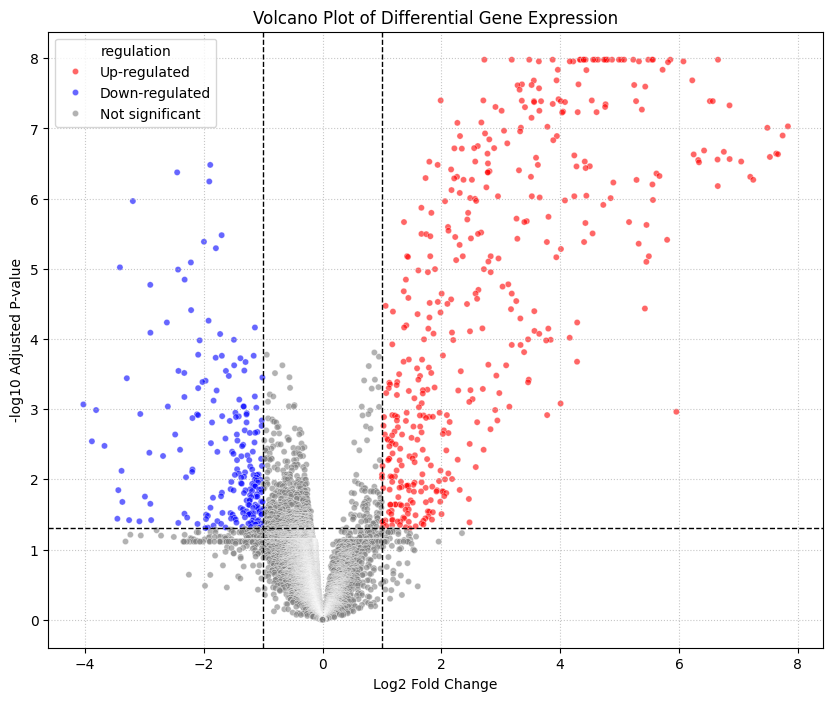

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
plot_df = LIMMA_RESULTS_DF.copy()

# Add a column for significance
plot_df['is_significant'] = (
    (plot_df['adj.P.Val'] < ADJ_P_VALUE_THRESHOLD) &
    (abs(plot_df['logFC']) > LOGFC_THRESHOLD)
)

# Add a column for 'regulation'
plot_df['regulation'] = 'Not significant'
plot_df.loc[plot_df['is_significant'] & (plot_df['logFC'] > LOGFC_THRESHOLD), 'regulation'] = 'Up-regulated'
plot_df.loc[plot_df['is_significant'] & (plot_df['logFC'] < -LOGFC_THRESHOLD), 'regulation'] = 'Down-regulated'

# -log10(adj.P.Val) for plotting
plot_df['-log10_adj_p_val'] = -np.log10(plot_df['adj.P.Val'])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df,
    x='logFC',
    y='-log10_adj_p_val',
    hue='regulation',
    palette={'Up-regulated': 'red', 'Down-regulated': 'blue', 'Not significant': 'grey'},
    alpha=0.6,
    s=20, # marker size
    legend='full'
)

# Add significance thresholds
plt.axvline(x=LOGFC_THRESHOLD, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-LOGFC_THRESHOLD, color='black', linestyle='--', linewidth=1)
plt.axhline(y=-np.log10(ADJ_P_VALUE_THRESHOLD), color='black', linestyle='--', linewidth=1)

plt.title('Volcano Plot of Differential Gene Expression')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-log10 Adjusted P-value')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Visualization: Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique used to highlight variation and bring out strong patterns in a dataset. In gene expression analysis, it helps to visualize global relationships between samples and identify potential batch effects or outliers. Here, we'll plot the first two principal components, colored by the sample group, to see how 'primary colorectal cancer' and 'metastatic colorectal cancer to the liver' samples cluster.

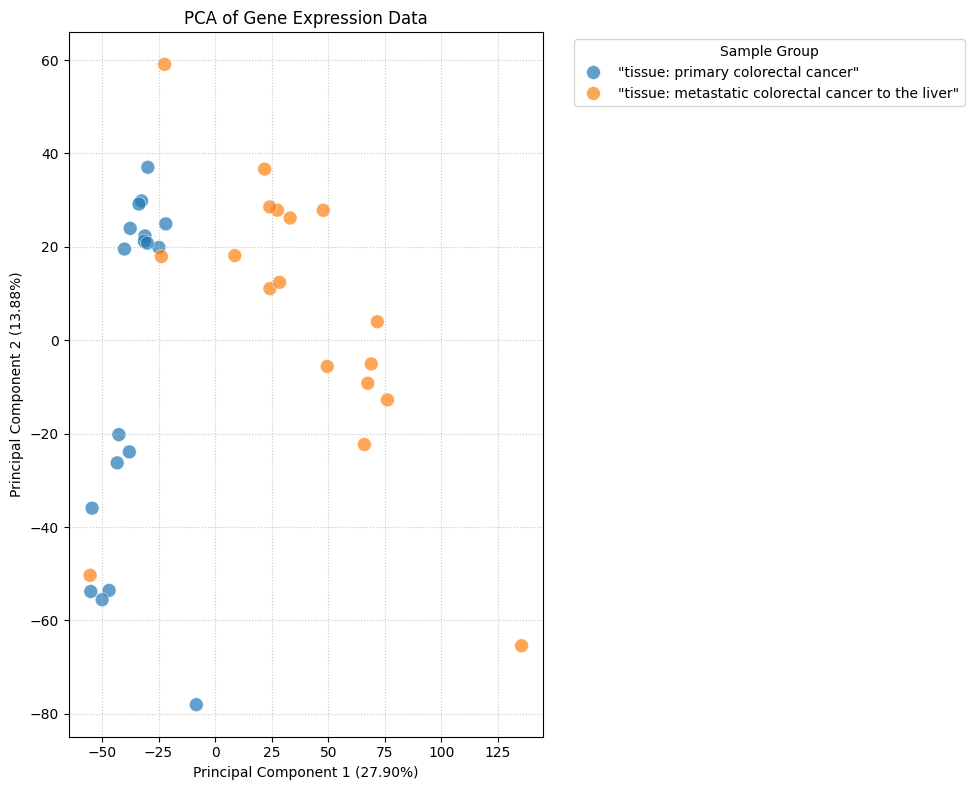

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Perform PCA on the log2-transformed gene expression data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log2_counts)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data = pca_result, columns = ['PC1', 'PC2'], index=log2_counts.index)

# Add the group information from COL_DATA to the PCA DataFrame for coloring the plot
pca_df = pca_df.merge(COL_DATA[[GROUP_COLUMN]], left_index=True, right_index=True)

# Plot the PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue=GROUP_COLUMN,
    s=100, # Marker size
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('PCA of Gene Expression Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Sample Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Visualization: Violin Plots for Selected DEGs

Violin plots are useful for visualizing the distribution of gene expression levels across different sample groups. We will select a few of the most significantly up-regulated and down-regulated genes and plot their log2-transformed expression values to observe the differences between 'primary colorectal cancer' and 'metastatic colorectal cancer to the liver' samples.

Plotting violin plots for selected genes: ['COLEC10', 'APOC4', 'APCS', 'LINC00578', 'FOXF1-AS1', 'WNT5A']


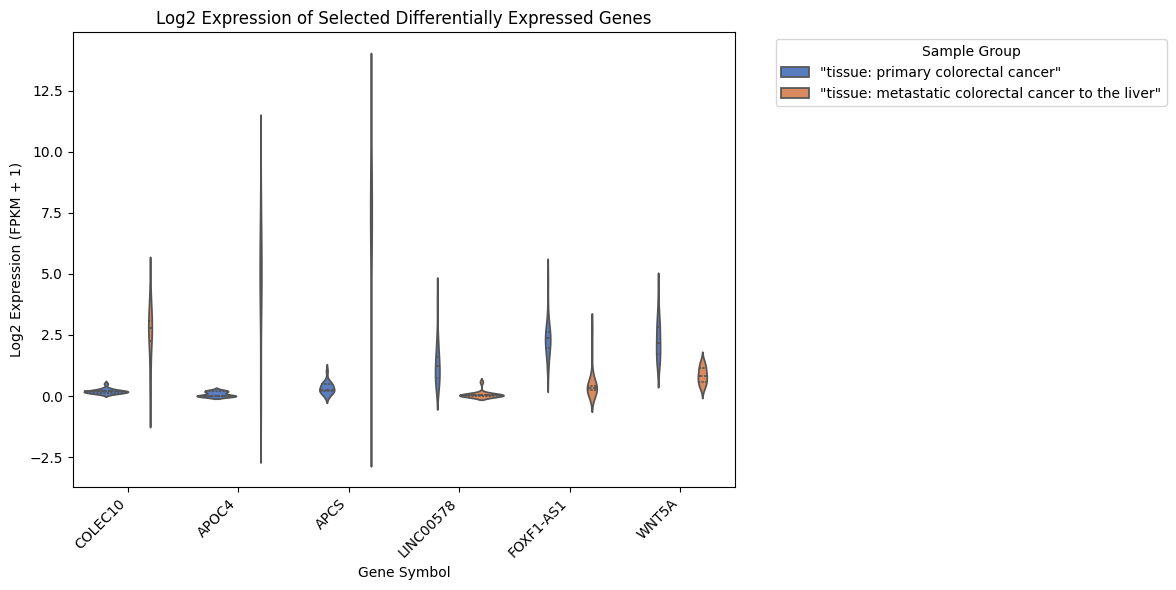

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select a few top up-regulated and down-regulated genes for violin plots
# Take top 3 from each category
selected_up_genes = top_20_up_regulated.index[:3].tolist()
selected_down_genes = top_20_down_regulated.index[:3].tolist()
selected_genes = selected_up_genes + selected_down_genes

print(f"Plotting violin plots for selected genes: {selected_genes}")

# Prepare data for violin plots
# Merge log2_counts with COL_DATA's GROUP_COLUMN
plot_data_violin = log2_counts.merge(COL_DATA[[GROUP_COLUMN]], left_index=True, right_index=True)

# Melt the DataFrame to a long format suitable for seaborn
plot_data_melted = plot_data_violin.melt(id_vars=[GROUP_COLUMN], value_vars=selected_genes, var_name='Gene', value_name='Log2_Expression')

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=plot_data_melted,
    x='Gene',
    y='Log2_Expression',
    hue=GROUP_COLUMN,
    inner='quartile',
    palette='muted'
)

plt.title('Log2 Expression of Selected Differentially Expressed Genes')
plt.xlabel('Gene Symbol')
plt.ylabel('Log2 Expression (FPKM + 1)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sample Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Functional Enrichment Analysis using gProfiler

Functional enrichment analysis helps to identify biological terms (e.g., Gene Ontology terms, pathways) that are over-represented in a given set of genes. This provides insights into the biological processes, molecular functions, and cellular components that are significantly impacted in our comparison of 'primary colorectal cancer' vs. 'metastatic colorectal cancer to the liver' samples. We will use `gprofiler-official` for this analysis.

### Subtask: Extract Gene Symbols

To perform functional enrichment analysis, we need lists of gene symbols. We will extract the gene symbols from the indices of our previously identified DataFrames: `DEGS_DF` (all differentially expressed genes), `UP_REGULATED_GENES` (up-regulated genes), and `DOWN_REGULATED_GENES` (down-regulated genes).

In [34]:
# Extract gene symbols from the indices of the DataFrames
all_degs_genes = DEGS_DF.index.tolist()
up_regulated_gene_list = UP_REGULATED_GENES.index.tolist()
down_regulated_gene_list = DOWN_REGULATED_GENES.index.tolist()

print(f"Number of all DEGs for enrichment: {len(all_degs_genes)}")
print(f"Number of up-regulated genes for enrichment: {len(up_regulated_gene_list)}")
print(f"Number of down-regulated genes for enrichment: {len(down_regulated_gene_list)}")

# Display first 10 gene symbols from each list as a preview
print("\nFirst 10 all DEGs:", all_degs_genes[:10])
print("First 10 up-regulated genes:", up_regulated_gene_list[:10])
print("First 10 down-regulated genes:", down_regulated_gene_list[:10])

Number of all DEGs for enrichment: 640
Number of up-regulated genes for enrichment: 429
Number of down-regulated genes for enrichment: 211

First 10 all DEGs: ['COLEC10', 'APOC4', 'APCS', 'CFHR2', 'IGFBP1', 'CPB2', 'C9', 'C8B', 'UGT2B4', 'LECT2']
First 10 up-regulated genes: ['COLEC10', 'APOC4', 'APCS', 'CFHR2', 'IGFBP1', 'CPB2', 'C9', 'C8B', 'UGT2B4', 'LECT2']
First 10 down-regulated genes: ['LINC00578', 'FOXF1-AS1', 'WNT5A', 'CCL11', 'TSPAN11', 'FOXF1', 'PCDH18', 'CTSK', 'VIP', 'MMP2']


### Subtask: Install gprofiler-official

Before running the enrichment analysis, we need to ensure that the `gprofiler-official` Python library is installed. This library provides a convenient interface to the gProfiler web server for functional enrichment analysis.

In [36]:
# Install gprofiler-official if not already installed
!pip install gprofiler-official

print("gprofiler-official library installed.")

gprofiler-official library installed.


### Subtask: Perform Functional Enrichment Analysis for All DEGs

Now, we will perform functional enrichment analysis for all identified differentially expressed genes using `gprofiler.GProfiler`. We will query for enriched Gene Ontology (GO) terms, pathways (KEGG, Reactome), and other relevant databases.

In [37]:
from gprofiler import GProfiler
import pandas as pd

# Initialize gProfiler
gp = GProfiler(return_dataframe=True)

print(f"Performing enrichment analysis for {len(all_degs_genes)} all DEGs...")

# Perform enrichment analysis for all DEGs
all_degs_enrichment = gp.profile(
    organism='hsapiens', # Human organism
    query=all_degs_genes,
    sources=['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC'], # Biological Process, Molecular Function, Cellular Component, KEGG, Reactome
    no_evidences=False # Include evidence codes
)

print("Enrichment analysis for all DEGs complete.")

# Display top 10 enriched terms
if not all_degs_enrichment.empty:
    print("\nTop 10 enriched terms for All DEGs (sorted by p_value):")
    display(all_degs_enrichment.head(10))
else:
    print("\nNo enriched terms found for All DEGs.")

# Store the results
ALL_DEGS_ENRICHMENT_RESULTS = all_degs_enrichment

Performing enrichment analysis for 640 all DEGs...
Enrichment analysis for all DEGs complete.

Top 10 enriched terms for All DEGs (sorted by p_value):


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:CC,GO:0005615,extracellular space,5.252526e-79,True,"""That part of a multicellular organism outside...",3252,595,280,22155,0.470588,0.086101,query_1,"[GO:0005576, GO:0110165]","[COLEC10, APOC4, APCS, CFHR2, IGFBP1, CPB2, C9...","[[IDA, IBA, NAS], [IDA, IMP, IBA, IEA], [IDA, ..."
1,GO:CC,GO:0005576,extracellular region,5.614769e-74,True,"""The space external to the outermost structure...",4249,595,313,22155,0.526050,0.073664,query_1,[GO:0110165],"[COLEC10, APOC4, APCS, CFHR2, IGFBP1, CPB2, C9...","[[IDA, IBA, TAS, NAS, IEA], [IDA, IMP, IBA, TA..."
2,KEGG,KEGG:04610,Complement and coagulation cascades,3.350310e-52,True,Complement and coagulation cascades,86,382,55,8716,0.143979,0.639535,query_1,[KEGG:00000],"[CFHR2, CPB2, C9, C8B, C8A, MBL2, F9, PLG, F2,...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
3,GO:BP,GO:0006082,organic acid metabolic process,3.927029e-51,True,"""The chemical reactions and pathways involving...",892,578,126,20972,0.217993,0.141256,query_1,[GO:0044281],"[CYP4A11, ARG1, FTCD, HAO1, ANGPTL3, APOA5, CY...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IEA], [IDA..."
4,GO:CC,GO:0072562,blood microparticle,2.624481e-50,True,"""A phospholipid microvesicle that is derived f...",138,595,57,22155,0.095798,0.413043,query_1,"[GO:0005615, GO:0110165]","[APCS, C9, C8A, ITIH1, ITIH2, HPR, PLG, AFM, F...","[[HDA], [HDA], [HDA], [HDA], [HDA], [HDA, IBA]..."
5,GO:BP,GO:0019752,carboxylic acid metabolic process,3.334838e-50,True,"""The chemical reactions and pathways involving...",863,578,123,20972,0.212803,0.142526,query_1,[GO:0043436],"[CYP4A11, ARG1, FTCD, HAO1, ANGPTL3, APOA5, CY...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IEA], [IDA..."
6,GO:BP,GO:0043436,oxoacid metabolic process,8.082300e-50,True,"""The chemical reactions and pathways involving...",885,578,124,20972,0.214533,0.140113,query_1,[GO:0006082],"[CYP4A11, ARG1, FTCD, HAO1, ANGPTL3, APOA5, CY...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IEA], [IDA..."
7,GO:BP,GO:0044281,small molecule metabolic process,1.269858e-44,True,"""The chemical reactions and pathways involving...",1694,578,163,20972,0.282007,0.096222,query_1,[GO:0008152],"[CYP4A11, ARG1, APOF, FTCD, APOB, HAO1, ANGPTL...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IBA, TAS, ..."
8,GO:CC,GO:1903561,extracellular vesicle,5.572976e-42,True,"""Any vesicle that is part of the extracellular...",2141,595,177,22155,0.297479,0.082672,query_1,"[GO:0031982, GO:0065010]","[APCS, CPB2, C9, C8B, C8A, ITIH1, FTCD, APOB, ...","[[HDA], [HDA], [HDA], [HDA], [HDA], [HDA], [HD..."
9,GO:CC,GO:0065010,extracellular membrane-bounded organelle,5.949110e-42,True,"""Organized structure of distinctive morphology...",2142,595,177,22155,0.297479,0.082633,query_1,"[GO:0043227, GO:0043230]","[APCS, CPB2, C9, C8B, C8A, ITIH1, FTCD, APOB, ...","[[HDA], [HDA], [HDA], [HDA], [HDA], [HDA], [HD..."


### Subtask: Perform Functional Enrichment Analysis for Up-regulated DEGs

Next, we will perform functional enrichment analysis specifically for the up-regulated differentially expressed genes. This will help us understand the biological processes and pathways that are activated in the metastatic samples compared to primary samples.

In [38]:
from gprofiler import GProfiler
import pandas as pd

# Initialize gProfiler (if not already initialized)
gp = GProfiler(return_dataframe=True)

print(f"Performing enrichment analysis for {len(up_regulated_gene_list)} up-regulated DEGs...")

# Perform enrichment analysis for up-regulated genes
up_regulated_enrichment = gp.profile(
    organism='hsapiens',
    query=up_regulated_gene_list,
    sources=['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC'],
    no_evidences=False
)

print("Enrichment analysis for up-regulated DEGs complete.")

# Display top 10 enriched terms
if not up_regulated_enrichment.empty:
    print("\nTop 10 enriched terms for Up-regulated DEGs (sorted by p_value):")
    display(up_regulated_enrichment.head(10))
else:
    print("\nNo enriched terms found for Up-regulated DEGs.")

# Store the results
UP_REGULATED_ENRICHMENT_RESULTS = up_regulated_enrichment

Performing enrichment analysis for 429 up-regulated DEGs...
Enrichment analysis for up-regulated DEGs complete.

Top 10 enriched terms for Up-regulated DEGs (sorted by p_value):


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:BP,GO:0006082,organic acid metabolic process,1.474229e-66,True,"""The chemical reactions and pathways involving...",892,391,120,20972,0.306905,0.134529,query_1,[GO:0044281],"[CYP4A11, ARG1, FTCD, HAO1, ANGPTL3, APOA5, CY...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IEA], [IDA..."
1,GO:BP,GO:0019752,carboxylic acid metabolic process,4.199029e-66,True,"""The chemical reactions and pathways involving...",863,391,118,20972,0.301790,0.136732,query_1,[GO:0043436],"[CYP4A11, ARG1, FTCD, HAO1, ANGPTL3, APOA5, CY...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IEA], [IDA..."
2,GO:BP,GO:0043436,oxoacid metabolic process,7.563770e-65,True,"""The chemical reactions and pathways involving...",885,391,118,20972,0.301790,0.133333,query_1,[GO:0006082],"[CYP4A11, ARG1, FTCD, HAO1, ANGPTL3, APOA5, CY...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IEA], [IDA..."
3,GO:CC,GO:0005615,extracellular space,4.474712e-59,True,"""That part of a multicellular organism outside...",3252,399,197,22155,0.493734,0.060578,query_1,"[GO:0005576, GO:0110165]","[COLEC10, APOC4, APCS, CFHR2, IGFBP1, CPB2, C9...","[[IDA, IBA, NAS], [IDA, IMP, IBA, IEA], [IDA, ..."
4,GO:BP,GO:0044281,small molecule metabolic process,1.147185e-58,True,"""The chemical reactions and pathways involving...",1694,391,148,20972,0.378517,0.087367,query_1,[GO:0008152],"[CYP4A11, ARG1, APOF, FTCD, APOB, HAO1, ANGPTL...","[[IDA, IBA, TAS, IEA], [TAS, IEA], [IBA, TAS, ..."
5,GO:CC,GO:0072562,blood microparticle,1.208718e-55,True,"""A phospholipid microvesicle that is derived f...",138,399,54,22155,0.135338,0.391304,query_1,"[GO:0005615, GO:0110165]","[APCS, C9, C8A, ITIH1, ITIH2, HPR, PLG, AFM, F...","[[HDA], [HDA], [HDA], [HDA], [HDA], [HDA, IBA]..."
6,GO:CC,GO:0005576,extracellular region,1.107140e-51,True,"""The space external to the outermost structure...",4249,399,214,22155,0.536341,0.050365,query_1,[GO:0110165],"[COLEC10, APOC4, APCS, CFHR2, IGFBP1, CPB2, C9...","[[IDA, IBA, TAS, NAS, IEA], [IDA, IMP, IBA, TA..."
7,KEGG,KEGG:04610,Complement and coagulation cascades,1.594826e-49,True,Complement and coagulation cascades,86,282,49,8716,0.173759,0.569767,query_1,[KEGG:00000],"[CFHR2, CPB2, C9, C8B, C8A, MBL2, F9, PLG, F2,...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
8,GO:BP,GO:0032787,monocarboxylic acid metabolic process,1.125055e-44,True,"""The chemical reactions and pathways involving...",604,391,83,20972,0.212276,0.137417,query_1,[GO:0019752],"[CYP4A11, HAO1, ANGPTL3, APOA5, CYP8B1, ADH1A,...","[[IDA, IBA, TAS, IEA], [IDA], [IDA], [IDA], [I..."
9,GO:CC,GO:1903561,extracellular vesicle,2.423373e-38,True,"""Any vesicle that is part of the extracellular...",2141,399,135,22155,0.338346,0.063055,query_1,"[GO:0031982, GO:0065010]","[APCS, CPB2, C9, C8B, C8A, ITIH1, FTCD, APOB, ...","[[HDA], [HDA], [HDA], [HDA], [HDA], [HDA], [HD..."


### Subtask: Perform Functional Enrichment Analysis for Down-regulated DEGs

Finally, we will perform functional enrichment analysis for the down-regulated differentially expressed genes. This will provide insights into the biological processes and pathways that are suppressed in the metastatic samples.

In [39]:
from gprofiler import GProfiler
import pandas as pd

# Initialize gProfiler (if not already initialized)
gp = GProfiler(return_dataframe=True)

print(f"Performing enrichment analysis for {len(down_regulated_gene_list)} down-regulated DEGs...")

# Perform enrichment analysis for down-regulated genes
down_regulated_enrichment = gp.profile(
    organism='hsapiens',
    query=down_regulated_gene_list,
    sources=['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC'],
    no_evidences=False
)

print("Enrichment analysis for down-regulated DEGs complete.")

# Display top 10 enriched terms
if not down_regulated_enrichment.empty:
    print("\nTop 10 enriched terms for Down-regulated DEGs (sorted by p_value):")
    display(down_regulated_enrichment.head(10))
else:
    print("\nNo enriched terms found for Down-regulated DEGs.")

# Store the results
DOWN_REGULATED_ENRICHMENT_RESULTS = down_regulated_enrichment

Performing enrichment analysis for 211 down-regulated DEGs...
Enrichment analysis for down-regulated DEGs complete.

Top 10 enriched terms for Down-regulated DEGs (sorted by p_value):


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:CC,GO:0005576,extracellular region,1.505927e-20,True,"""The space external to the outermost structure...",4249,196,99,22155,0.505102,0.023300,query_1,[GO:0110165],"[WNT5A, CCL11, CTSK, VIP, MMP2, VWF, FBLN1, CO...","[[IDA, IBA, TAS, IEA], [IDA, IBA, TAS, IEA], [..."
1,GO:CC,GO:0005615,extracellular space,1.624734e-18,True,"""That part of a multicellular organism outside...",3252,196,83,22155,0.423469,0.025523,query_1,"[GO:0005576, GO:0110165]","[WNT5A, CCL11, CTSK, VIP, MMP2, VWF, FBLN1, CO...","[[IDA, IBA, TAS], [IBA, IEA], [IDA, IBA, IEA],..."
2,GO:BP,GO:0009653,anatomical structure morphogenesis,2.194270e-14,True,"""The process in which anatomical structures ar...",2699,187,70,20972,0.374332,0.025936,query_1,"[GO:0032502, GO:0048856]","[WNT5A, CCL11, FOXF1, MMP2, COL12A1, FOXF2, RG...","[[IMP, ISS, IEA], [IDA, IEA], [IMP, IBA, IEA],..."
3,GO:BP,GO:0030198,extracellular matrix organization,8.563049e-14,True,"""A process that is carried out at the cellular...",307,187,25,20972,0.133690,0.081433,query_1,"[GO:0043062, GO:0045229]","[FOXF1, CTSK, MMP2, FBLN1, COL12A1, FOXF2, MMP...","[[IEA], [TAS], [IBA, TAS], [IEA], [NAS], [IEA]..."
4,GO:BP,GO:0043062,extracellular structure organization,9.249532e-14,True,"""A process that is carried out at the cellular...",308,187,25,20972,0.133690,0.081169,query_1,[GO:0016043],"[FOXF1, CTSK, MMP2, FBLN1, COL12A1, FOXF2, MMP...","[[IEA], [TAS], [IBA, TAS], [IEA], [NAS], [IEA]..."
5,GO:BP,GO:0045229,external encapsulating structure organization,9.988191e-14,True,"""A process that is carried out at the cellular...",309,187,25,20972,0.133690,0.080906,query_1,[GO:0016043],"[FOXF1, CTSK, MMP2, FBLN1, COL12A1, FOXF2, MMP...","[[IEA], [TAS], [IBA, TAS], [IEA], [NAS], [IEA]..."
6,GO:CC,GO:0031012,extracellular matrix,1.420357e-13,True,"""A structure lying external to one or more cel...",339,196,25,22155,0.127551,0.073746,query_1,[GO:0030312],"[WNT5A, MMP2, VWF, FBLN1, COL12A1, MMP3, LAMA4...","[[IEA], [IEA], [IBA], [IDA, IEA], [TAS, NAS], ..."
7,GO:CC,GO:0030312,external encapsulating structure,1.521580e-13,True,"""A structure that lies outside the plasma memb...",340,196,25,22155,0.127551,0.073529,query_1,"[GO:0071944, GO:0110165]","[WNT5A, MMP2, VWF, FBLN1, COL12A1, MMP3, LAMA4...","[[IEA], [IEA], [IBA], [IDA, IEA], [TAS, NAS], ..."
8,GO:BP,GO:0032501,multicellular organismal process,2.064195e-12,True,"""Any biological process, occurring at the leve...",7337,187,119,20972,0.636364,0.016219,query_1,[GO:0008150],"[WNT5A, CCL11, FOXF1, PCDH18, CTSK, MMP2, VWF,...","[[IMP, IEP, ISS, IBA, TAS, NAS, IEA], [ISS, IE..."
9,REAC,REAC:R-HSA-1474244,Extracellular matrix organization,2.925439e-10,True,Extracellular matrix organization,298,119,22,11056,0.184874,0.073826,query_1,[REAC:0000000],"[CTSK, MMP2, VWF, FBLN1, COL12A1, MMP3, LAMA4,...","[[REAC], [REAC], [REAC], [REAC], [REAC], [REAC..."


### Top 20 Up-regulated Genes

In [25]:
display(UP_REGULATED_GENES.head(20))

,logFC,AveExpr,t,P.Value,adj.P.Val,B
COLEC10,2.723789,1.952373,10.389794,1.254251e-12,1.049901e-08,18.640415
APOC4,5.032969,2.878667,10.354848,1.379254e-12,1.049901e-08,18.622726
APCS,6.657316,4.137929,10.162940,2.330552e-12,1.049901e-08,18.053543
CFHR2,5.231119,3.018293,10.162219,2.335173e-12,1.049901e-08,18.108425
IGFBP1,5.854544,3.633998,10.139944,2.482549e-12,1.049901e-08,18.011276
CPB2,4.873111,2.787304,10.061944,3.077431e-12,1.049901e-08,17.840995
C9,5.483765,3.239533,10.035490,3.310601e-12,1.049901e-08,17.762774
C8B,5.076506,2.959546,9.965712,4.015691e-12,1.049901e-08,17.579393
UGT2B4,4.586345,2.654418,9.904509,4.759205e-12,1.049901e-08,17.415302
LECT2,3.873437,2.218507,9.864803,5.315080e-12,1.049901e-08,17.303901


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### Top 20 Down-regulated Genes

In [26]:
display(DOWN_REGULATED_GENES.head(20))

,logFC,AveExpr,t,P.Value,adj.P.Val,B
LINC00578,-1.891366,1.146515,-7.900978,1.604200e-09,3.308257e-07,11.741827
FOXF1-AS1,-2.448080,2.113262,-7.794772,2.212706e-09,4.229147e-07,11.417440
WNT5A,-1.907213,2.365701,-7.665852,3.274397e-09,5.702059e-07,11.006544
CCL11,-3.193685,3.295821,-7.414735,7.058004e-09,1.084488e-06,10.292855
TSPAN11,-1.699007,1.653776,-7.008848,2.471168e-08,3.319696e-06,9.099985
FOXF1,-1.997129,3.243524,-6.928793,3.168852e-08,4.115831e-06,8.857769
PCDH18,-1.795800,2.490487,-6.851789,4.026889e-08,5.089685e-06,8.623623
CTSK,-2.216878,5.269865,-6.680347,6.874840e-08,8.121639e-06,8.111512
VIP,-3.411389,2.388232,-6.627267,8.115901e-08,9.539836e-06,7.938494
MMP2,-2.433037,5.914101,-6.599057,8.864760e-08,1.026609e-05,7.862467


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# Task
Perform a differential gene expression (DGE) analysis on a human cancer dataset (GSE50760) comparing 'liver metastasis' samples against 'primary colorectal cancer' samples using the `limma` package in R via `rpy2`. The analysis will involve data preprocessing, `voom` transformation, linear model fitting, empirical Bayes moderation, and extraction of differentially expressed genes. Finally, summarize the findings.

## Prepare_Top_Gene_Tables

### Subtask:
Extract the top 20 rows from the `DEGS_DF`, `UP_REGULATED_GENES`, and `DOWN_REGULATED_GENES` DataFrames to prepare them for saving.


**Reasoning**:
Extracting the top 20 rows for each category of genes (all DEGs, up-regulated, and down-regulated) to prepare them for reporting.



In [27]:
import pandas as pd

# 1. Create a new DataFrame `top_20_degs` by selecting the first 20 rows from `DEGS_DF`.
top_20_degs = DEGS_DF.head(20)
print("Top 20 Differentially Expressed Genes:")
display(top_20_degs)

# 2. Create a new DataFrame `top_20_up_regulated` by selecting the first 20 rows from `UP_REGULATED_GENES`.
top_20_up_regulated = UP_REGULATED_GENES.head(20)
print("\nTop 20 Up-regulated Genes:")
display(top_20_up_regulated)

# 3. Create a new DataFrame `top_20_down_regulated` by selecting the first 20 rows from `DOWN_REGULATED_GENES`.
top_20_down_regulated = DOWN_REGULATED_GENES.head(20)
print("\nTop 20 Down-regulated Genes:")
display(top_20_down_regulated)


Top 20 Differentially Expressed Genes:


,logFC,AveExpr,t,P.Value,adj.P.Val,B
COLEC10,2.723789,1.952373,10.389794,1.254251e-12,1.049901e-08,18.640415
APOC4,5.032969,2.878667,10.354848,1.379254e-12,1.049901e-08,18.622726
APCS,6.657316,4.137929,10.162940,2.330552e-12,1.049901e-08,18.053543
CFHR2,5.231119,3.018293,10.162219,2.335173e-12,1.049901e-08,18.108425
IGFBP1,5.854544,3.633998,10.139944,2.482549e-12,1.049901e-08,18.011276
CPB2,4.873111,2.787304,10.061944,3.077431e-12,1.049901e-08,17.840995
C9,5.483765,3.239533,10.035490,3.310601e-12,1.049901e-08,17.762774
C8B,5.076506,2.959546,9.965712,4.015691e-12,1.049901e-08,17.579393
UGT2B4,4.586345,2.654418,9.904509,4.759205e-12,1.049901e-08,17.415302
LECT2,3.873437,2.218507,9.864803,5.315080e-12,1.049901e-08,17.303901



Top 20 Up-regulated Genes:


,logFC,AveExpr,t,P.Value,adj.P.Val,B
COLEC10,2.723789,1.952373,10.389794,1.254251e-12,1.049901e-08,18.640415
APOC4,5.032969,2.878667,10.354848,1.379254e-12,1.049901e-08,18.622726
APCS,6.657316,4.137929,10.162940,2.330552e-12,1.049901e-08,18.053543
CFHR2,5.231119,3.018293,10.162219,2.335173e-12,1.049901e-08,18.108425
IGFBP1,5.854544,3.633998,10.139944,2.482549e-12,1.049901e-08,18.011276
CPB2,4.873111,2.787304,10.061944,3.077431e-12,1.049901e-08,17.840995
C9,5.483765,3.239533,10.035490,3.310601e-12,1.049901e-08,17.762774
C8B,5.076506,2.959546,9.965712,4.015691e-12,1.049901e-08,17.579393
UGT2B4,4.586345,2.654418,9.904509,4.759205e-12,1.049901e-08,17.415302
LECT2,3.873437,2.218507,9.864803,5.315080e-12,1.049901e-08,17.303901



Top 20 Down-regulated Genes:


,logFC,AveExpr,t,P.Value,adj.P.Val,B
LINC00578,-1.891366,1.146515,-7.900978,1.604200e-09,3.308257e-07,11.741827
FOXF1-AS1,-2.448080,2.113262,-7.794772,2.212706e-09,4.229147e-07,11.417440
WNT5A,-1.907213,2.365701,-7.665852,3.274397e-09,5.702059e-07,11.006544
CCL11,-3.193685,3.295821,-7.414735,7.058004e-09,1.084488e-06,10.292855
TSPAN11,-1.699007,1.653776,-7.008848,2.471168e-08,3.319696e-06,9.099985
FOXF1,-1.997129,3.243524,-6.928793,3.168852e-08,4.115831e-06,8.857769
PCDH18,-1.795800,2.490487,-6.851789,4.026889e-08,5.089685e-06,8.623623
CTSK,-2.216878,5.269865,-6.680347,6.874840e-08,8.121639e-06,8.111512
VIP,-3.411389,2.388232,-6.627267,8.115901e-08,9.539836e-06,7.938494
MMP2,-2.433037,5.914101,-6.599057,8.864760e-08,1.026609e-05,7.862467


## Save_To_Excel

### Subtask:
Save the three prepared gene tables (top 20 DEGs, top 20 up-regulated, top 20 down-regulated) into a single Excel file with each table on a separate sheet.


**Reasoning**:
I need to implement the instructions to save the three DataFrames into a single Excel file with multiple sheets. This involves importing `ExcelWriter`, creating an `ExcelWriter` object, writing each DataFrame to a separate sheet using `.to_excel()`, and then saving/closing the writer.



In [31]:
import pandas as pd

# Define the output Excel filename
output_excel_file = 'top_20_genes.xlsx'

# Create a Pandas Excel writer using XlsxWriter as the engine.
# The 'with' statement ensures the writer is properly closed even if errors occur.
with pd.ExcelWriter(output_excel_file, engine='xlsxwriter') as writer:
    # Write each DataFrame to a different sheet
    top_20_degs.to_excel(writer, sheet_name='Top 20 DEGs', index=True)
    top_20_up_regulated.to_excel(writer, sheet_name='Top 20 Up-regulated', index=True)
    top_20_down_regulated.to_excel(writer, sheet_name='Top 20 Down-regulated', index=True)

print(f"Successfully saved top gene lists to '{output_excel_file}'.")

Successfully saved top gene lists to 'top_20_genes.xlsx'.


**Reasoning**:
Install the missing `xlsxwriter` library to enable writing Excel files with pandas.



In [29]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 2.4 MB/s eta 0:00:00


**Reasoning**:
The `xlsxwriter` package is now installed. I need to re-run the code to save the DataFrames to an Excel file using `pd.ExcelWriter` with the `xlsxwriter` engine, as specified in the subtask instructions.



In [30]:
import pandas as pd

# Define the output Excel filename
output_excel_file = 'top_20_genes.xlsx'

# Create a Pandas Excel writer using XlsxWriter as the engine.
# The 'with' statement ensures the writer is properly closed even if errors occur.
with pd.ExcelWriter(output_excel_file, engine='xlsxwriter') as writer:
    # Write each DataFrame to a different sheet
    top_20_degs.to_excel(writer, sheet_name='Top 20 DEGs', index=True)
    top_20_up_regulated.to_excel(writer, sheet_name='Top 20 Up-regulated', index=True)
    top_20_down_regulated.to_excel(writer, sheet_name='Top 20 Down-regulated', index=True)

print(f"Successfully saved top gene lists to '{output_excel_file}'.")

Successfully saved top gene lists to 'top_20_genes.xlsx'.


## Visualization: Clustered Heatmap for Top DEGs

A clustered heatmap provides a visual representation of gene expression levels across samples, where both genes and samples are hierarchically clustered based on similarity. This helps in identifying groups of genes with similar expression patterns and discerning sample relationships.

We will create a heatmap for the top 50 differentially expressed genes (DEGs) to illustrate their expression profiles across the primary colorectal cancer and liver metastasis samples.

### Visualization: Functional Enrichment Bar Plots

These bar plots display the top enriched terms (sorted by adjusted p-value) for All Differentially Expressed Genes (DEGs), Up-regulated DEGs, and Down-regulated DEGs. The length of each bar represents the -log10 of the adjusted p-value, indicating the significance of the enrichment.

/tmp/ipykernel_22208/3543000952.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


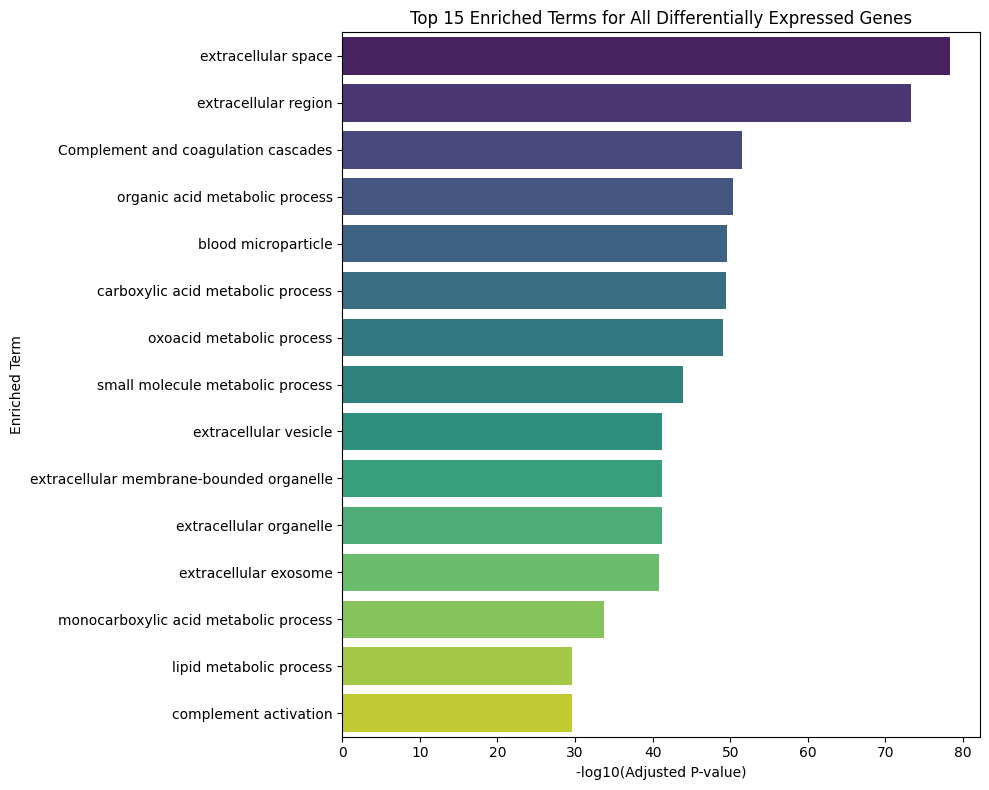

/tmp/ipykernel_22208/3543000952.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


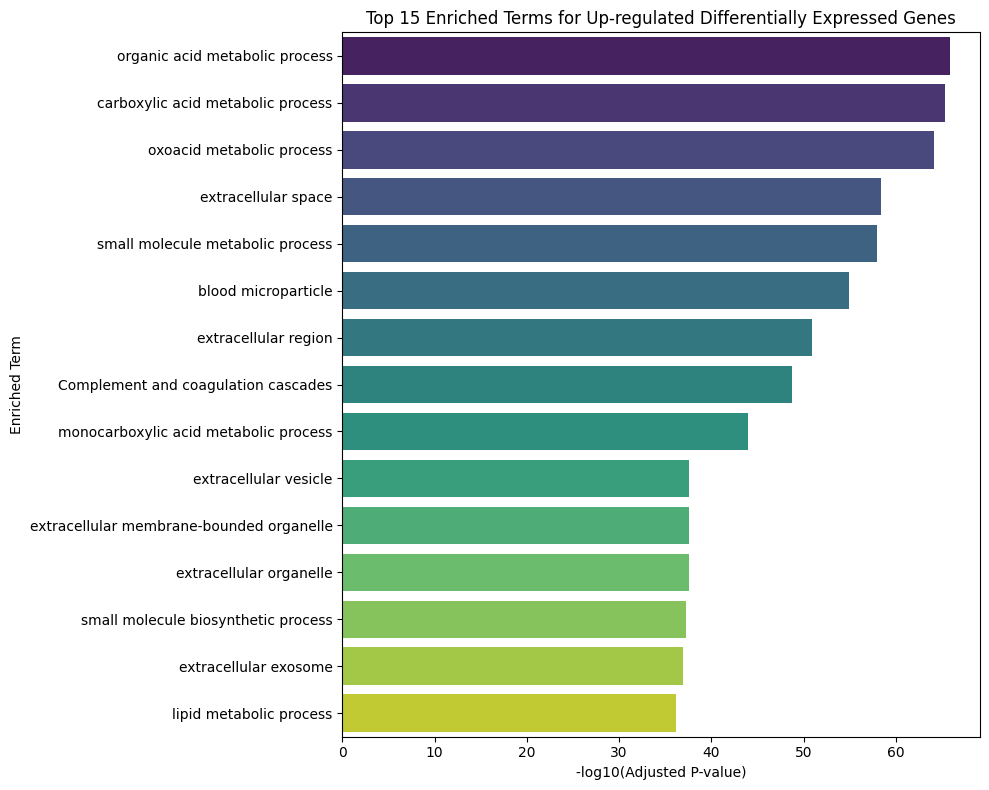

/tmp/ipykernel_22208/3543000952.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


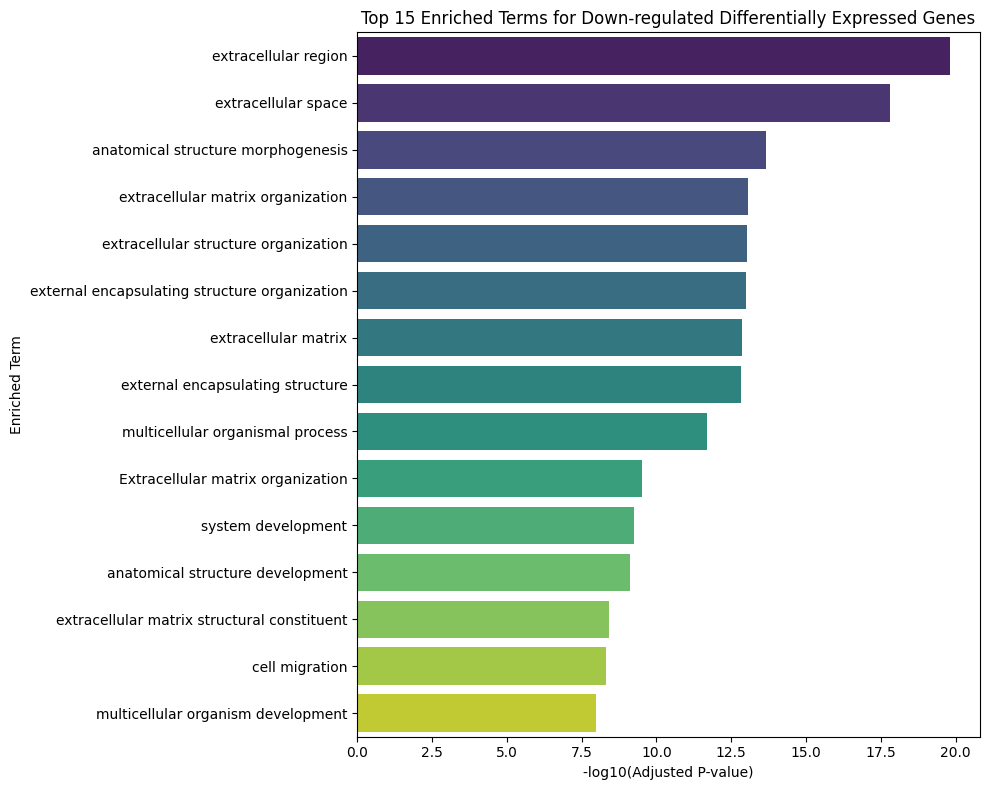

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_enrichment_results(enrichment_df, title, num_terms=15):
    if enrichment_df.empty:
        print(f"No enrichment results to plot for: {title}")
        return

    # Sort by p_value and take the top N terms
    plot_df = enrichment_df.sort_values(by='p_value', ascending=True).head(num_terms).copy()
    plot_df['-log10_p_value'] = -np.log10(plot_df['p_value'])

    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='-log10_p_value',
        y='name',
        data=plot_df,
        palette='viridis',
        orient='h'
    )
    plt.title(f'Top {num_terms} Enriched Terms for {title}')
    plt.xlabel('-log10(Adjusted P-value)')
    plt.ylabel('Enriched Term')
    plt.tight_layout()
    plt.show()

# Plot for All DEGs
plot_enrichment_results(ALL_DEGS_ENRICHMENT_RESULTS, 'All Differentially Expressed Genes')

# Plot for Up-regulated DEGs
plot_enrichment_results(UP_REGULATED_ENRICHMENT_RESULTS, 'Up-regulated Differentially Expressed Genes')

# Plot for Down-regulated DEGs
plot_enrichment_results(DOWN_REGULATED_ENRICHMENT_RESULTS, 'Down-regulated Differentially Expressed Genes')

<Figure size 1200x1500 with 0 Axes>

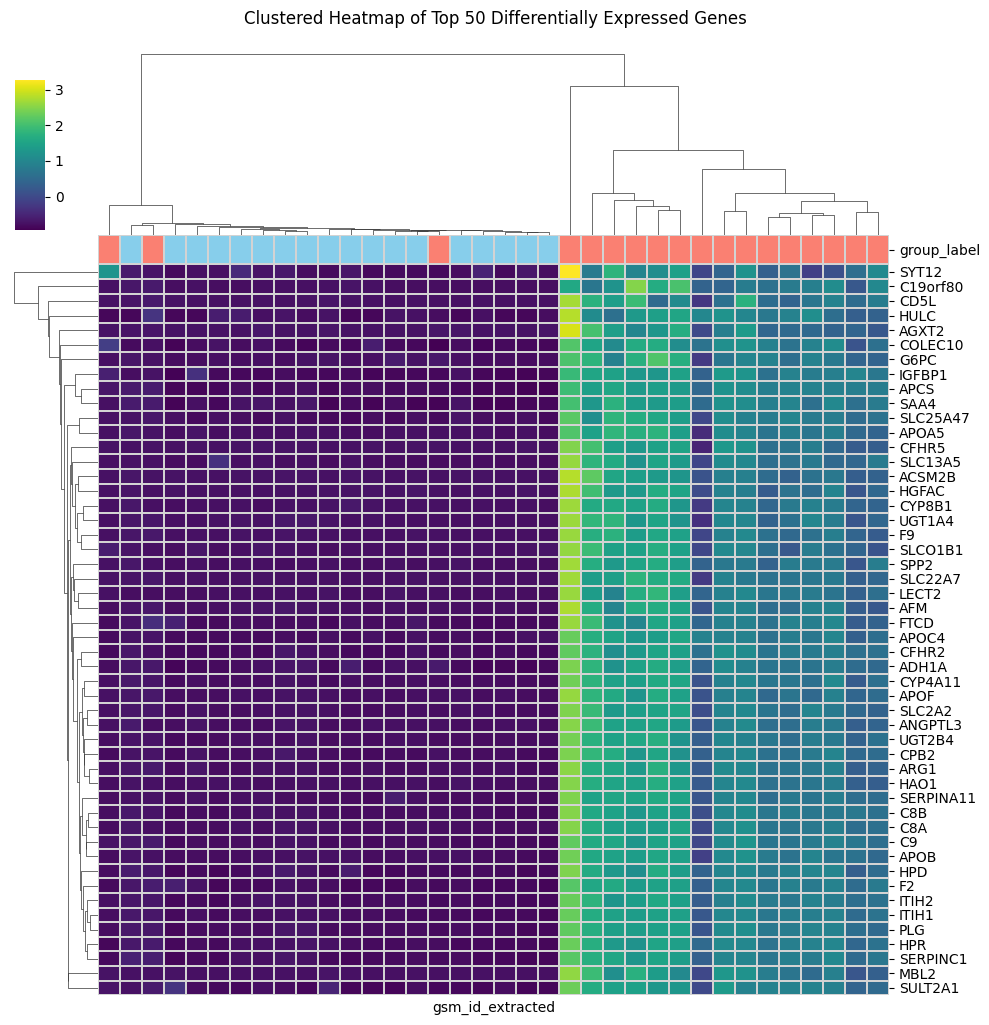

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select the top N DEGs for heatmap visualization to keep it readable
num_top_degs_heatmap = 50
top_degs_for_heatmap = DEGS_DF.head(num_top_degs_heatmap).index.tolist()

# Filter the log2-transformed counts for these top DEGs
# Ensure genes are columns and samples are rows for direct filtering
expression_for_heatmap = log2_counts[top_degs_for_heatmap]

# For the heatmap, it's conventional to have genes as rows and samples as columns
# So, we transpose the DataFrame for visualization
expression_for_heatmap_T = expression_for_heatmap.T

# Prepare annotation for samples (columns of the transposed matrix)
# This will be used to color code samples based on their group
sample_annotation = COL_DATA[[GROUP_COLUMN]]
sample_annotation.index.name = 'Sample'

# Ensure sample_annotation index matches the columns of expression_for_heatmap_T
sample_annotation_ordered = sample_annotation.loc[expression_for_heatmap_T.columns]

# Map group names to more readable labels for the heatmap
# This assumes GROUP_COLUMN contains the labels '"tissue: primary colorectal cancer"' and '"tissue: metastatic colorectal cancer to the liver"'
# We need to strip quotes and replace spaces for cleaner labels
sample_annotation_ordered['group_label'] = sample_annotation_ordered[GROUP_COLUMN].str.strip('"').str.replace('tissue: ', '').str.replace('_', ' ')

# Create a color map for the sample groups
unique_groups = sample_annotation_ordered['group_label'].unique()
if len(unique_groups) <= 2:
    palette = {'primary colorectal cancer': 'skyblue', 'metastatic colorectal cancer to the liver': 'salmon'}
else:
    palette = sns.color_palette("Paired", len(unique_groups)).as_hex()
    palette = dict(zip(unique_groups, palette))

row_colors = sample_annotation_ordered['group_label'].map(palette)

plt.figure(figsize=(12, 15))

# Generate the clustered heatmap
sns.clustermap(
    expression_for_heatmap_T, # Data for the heatmap (genes as rows, samples as columns)
    cmap='viridis', # Colormap
    z_score=0, # Row-wise z-score normalization for better comparison of gene expression
    col_colors=row_colors, # Colors for sample annotations
    dendrogram_ratio=(0.1, 0.2), # Adjust dendrogram sizes
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of the colorbar
    linewidths=0.01, # Line width between cells
    linecolor='lightgrey', # Line color between cells
    yticklabels=True, # Show gene labels on y-axis
    xticklabels=False # Hide sample labels on x-axis (can be too crowded)
)

plt.suptitle(f'Clustered Heatmap of Top {num_top_degs_heatmap} Differentially Expressed Genes', y=1.02) # Add a main title
plt.show()

## Gene Set Enrichment Analysis (GSEA)

Gene Set Enrichment Analysis (GSEA) is a computational method that determines whether a predefined set of genes shows a statistically significant, concordant difference in expression between two biological states. Unlike ORA, GSEA does not require a hard cutoff for differential expression; instead, it uses a ranked list of all genes. Here, we will use the `GSEApy` library to perform a preranked GSEA.

### Subtask: Install GSEApy

In [41]:
# Install gseapy if not already installed
!pip install gseapy

print("GSEApy library installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 5.5 MB/s eta 0:00:00
GSEApy library installed.


### Subtask: Prepare Ranked Gene List for GSEA

GSEA requires a ranked list of genes. A common ranking metric is the sign of the logFC multiplied by the negative log10 of the P-value. This metric gives higher scores to genes that are both highly differentially expressed and highly significant.

In [42]:
import numpy as np
import pandas as pd

# Ensure that the index is named 'gene_name' for GSEApy compatibility
# And remove any potential duplicate gene names if not already handled
ranked_gene_list = LIMMA_RESULTS_DF.copy()
ranked_gene_list.index.name = 'gene_name'

# Calculate a ranking metric: sign(logFC) * -log10(P.Value)
# Handle potential P.Value = 0 by replacing with a very small number if any
ranked_gene_list['P.Value_adjusted'] = ranked_gene_list['P.Value'].replace(0, np.finfo(float).eps)
ranked_gene_list['ranking_metric'] = ranked_gene_list['logFC'] * (-np.log10(ranked_gene_list['P.Value_adjusted']))

# Sort the genes by the ranking metric in descending order
ranked_gene_list = ranked_gene_list.sort_values(by='ranking_metric', ascending=False)

# Extract the gene names and their ranking metrics into a Series
gsea_gene_ranking = ranked_gene_list['ranking_metric']

print("First 10 genes in the ranked list for GSEA:")
display(gsea_gene_ranking.head(10))

# Store the ranked list
GSEA_GENE_RANKING = gsea_gene_ranking

First 10 genes in the ranked list for GSEA:


,ranking_metric
gene_name,
APCS,77.441508
HP,74.583557
APOC3,72.427537
APOA2,71.005808
ORM1,69.100612
APOA1,68.970720
IGFBP1,67.942577
FGL1,67.873108
FGG,67.479843


### Subtask: Perform Preranked GSEA

Now, we will run the preranked GSEA using the `GSEApy` library. We'll use gene set databases like KEGG and Gene Ontology (Biological Process) to identify significantly enriched pathways.

In [43]:
import gseapy as gp

print("Performing preranked GSEA...")

# Run preranked GSEA
# We'll use MSigDB's 'KEGG_2021_Human' and 'GO_BP_2021' gene set libraries.
# The `permutation_num` can be increased for more robust results, but 100 is good for initial run.
gsea_results = gp.prerank(
    rnk=GSEA_GENE_RANKING, # ranked gene list
    gene_sets=['KEGG_2021_Human', 'GO_BP_2021'], # gene set libraries to use
    no_plot=True, # Do not plot individual enrichment scores for now
    ofname='gseapy_prerank_output', # Output file name prefix
    min_size=5, max_size=1000, # Min and max size of gene sets to consider
    permutation_num=100, # Number of permutations for significance calculation
    outdir=None, # By default, results will be in the current directory, set to None to return df directly
    format='png' # Output plot format
)

print("Preranked GSEA complete.")

# Display top 10 enriched terms from KEGG
print("\nTop 10 enriched KEGG pathways from GSEA:")
display(gsea_results.res2d.head(10))

# Store the GSEA results
GSEA_RESULTS = gsea_results

2026-06-07 15:10:58,017 [WARNING] Duplicated values found in preranked stats: 11.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Performing preranked GSEA...


2026-06-07 15:10:58,568 [ERROR] No supported gene_sets: GO_BP_2021


Preranked GSEA complete.

Top 10 enriched KEGG pathways from GSEA:


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,KEGG_2021_Human__IL-17 signaling pathway,-0.77544,-1.85875,0.01,0.010000,0.01,22/92,7.04%,CCL11;MMP3;MMP1;CSF3;LCN2;MMP13;IL17B;MUC5B;CX...
1,prerank,KEGG_2021_Human__Pathways of neurodegeneration,-0.585951,-1.788716,0.01,0.010000,0.01,96/443,15.08%,WNT5A;WNT2B;ATP2A3;PRPH;NOS2;TUBAL3;COX6B2;WNT...
2,prerank,KEGG_2021_Human__GnRH signaling pathway,-0.71182,-1.739918,0.01,0.014011,0.03,34/93,12.31%,MMP2;ADCY2;MAP2K6;GNA11;PLA2G4A;ADCY4;PRKACB;A...
3,prerank,KEGG_2021_Human__Oxytocin signaling pathway,-0.606948,-1.721295,0.01,0.017514,0.05,52/152,15.20%,PPP1R12B;ADCY2;MYLK;MYL9;PLA2G4A;ADCY4;MAP2K5;...
4,prerank,KEGG_2021_Human__Asthma,-0.849344,-1.721118,0.01,0.014011,0.05,2/30,1.40%,CCL11;MS4A2
5,prerank,KEGG_2021_Human__Axon guidance,-0.663835,-1.692376,0.01,0.018681,0.08,53/180,13.37%,WNT5A;RGMA;BOC;MYL9;SEMA6A;EPHA4;SLIT3;WNT5B;S...
6,prerank,KEGG_2021_Human__Drug metabolism,0.948438,1.659094,0.01,0.010000,0.01,29/107,1.63%,CYP2E1;ADH1A;UGT2B4;CYP2C8;ADH4;UGT1A4;CYP3A4;...
7,prerank,KEGG_2021_Human__Metabolism of xenobiotics by ...,0.952244,1.658487,0.01,0.010000,0.01,29/75,2.17%,CYP2E1;ADH1A;UGT2B4;SULT2A1;ADH4;UGT1A4;CYP3A4...
8,prerank,KEGG_2021_Human__Gap junction,-0.717405,-1.652273,0.01,0.032025,0.13,27/86,11.41%,LPAR1;PDGFRA;ADCY2;GJA1;TUBAL3;PRKG1;TUBB4A;GN...
9,prerank,KEGG_2021_Human__Tyrosine metabolism,0.946987,1.649508,0.01,0.010000,0.01,11/36,1.65%,HPD;ADH1A;ADH4;TAT;AOX1;ADH1B;MAOB;DBH;FAH;ADH...


### Subtask: Re-run Preranked GSEA with supported GO_BP Gene Set

Previously, `GSEApy` reported `GO_BP_2021` as an unsupported gene set. To address this, we will re-run the preranked GSEA using `GO_Biological_Process_2023`, a more current and widely supported Gene Ontology Biological Process gene set. This will allow us to obtain enrichment results for GO Biological Process terms.

In [46]:
import gseapy as gp

print("Performing preranked GSEA with updated gene sets...")

# Run preranked GSEA with the corrected GO_BP gene set
gsea_results_updated = gp.prerank(
    rnk=GSEA_GENE_RANKING, # ranked gene list
    gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2023'], # updated gene set libraries
    no_plot=True, # Do not plot individual enrichment scores for now
    ofname='gseapy_prerank_output_updated', # Output file name prefix
    min_size=5, max_size=1000, # Min and max size of gene sets to consider
    permutation_num=100, # Number of permutations for significance calculation
    outdir=None, # By default, results will be in the current directory, set to None to return df directly
    format='png' # Output plot format
)

print("Preranked GSEA with updated gene sets complete.")

# Display top 10 enriched terms from KEGG
print("\nTop 10 enriched KEGG pathways from GSEA (updated run):")
display(gsea_results_updated.res2d[gsea_results_updated.res2d['Term'].str.contains('KEGG_2021_Human')].head(10))

# Display top 10 enriched terms from GO Biological Process (if available)
print("\nTop 10 enriched GO Biological Process terms from GSEA (updated run):")
display(gsea_results_updated.res2d[gsea_results_updated.res2d['Term'].str.contains('GO_Biological_Process_2023')].head(10))

# Store the updated GSEA results
GSEA_RESULTS = gsea_results_updated

2026-06-07 15:16:09,786 [WARNING] Duplicated values found in preranked stats: 11.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Performing preranked GSEA with updated gene sets...
Preranked GSEA with updated gene sets complete.

Top 10 enriched KEGG pathways from GSEA (updated run):


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
2,prerank,KEGG_2021_Human__IL-17 signaling pathway,-0.77544,-1.85875,0.01,0.010000,0.01,22/92,7.04%,CCL11;MMP3;MMP1;CSF3;LCN2;MMP13;IL17B;MUC5B;CX...
7,prerank,KEGG_2021_Human__Pathways of neurodegeneration,-0.585951,-1.788716,0.01,0.010000,0.01,96/443,15.08%,WNT5A;WNT2B;ATP2A3;PRPH;NOS2;TUBAL3;COX6B2;WNT...
16,prerank,KEGG_2021_Human__GnRH signaling pathway,-0.71182,-1.739918,0.01,0.014011,0.03,34/93,12.31%,MMP2;ADCY2;MAP2K6;GNA11;PLA2G4A;ADCY4;PRKACB;A...
26,prerank,KEGG_2021_Human__Oxytocin signaling pathway,-0.606948,-1.721295,0.01,0.017514,0.05,52/152,15.20%,PPP1R12B;ADCY2;MYLK;MYL9;PLA2G4A;ADCY4;MAP2K5;...
27,prerank,KEGG_2021_Human__Asthma,-0.849344,-1.721118,0.01,0.014011,0.05,2/30,1.40%,CCL11;MS4A2
43,prerank,KEGG_2021_Human__Axon guidance,-0.663835,-1.692376,0.01,0.018681,0.08,53/180,13.37%,WNT5A;RGMA;BOC;MYL9;SEMA6A;EPHA4;SLIT3;WNT5B;S...
73,prerank,KEGG_2021_Human__Drug metabolism,0.948438,1.659094,0.01,0.010000,0.01,29/107,1.63%,CYP2E1;ADH1A;UGT2B4;CYP2C8;ADH4;UGT1A4;CYP3A4;...
74,prerank,KEGG_2021_Human__Metabolism of xenobiotics by ...,0.952244,1.658487,0.01,0.010000,0.01,29/75,2.17%,CYP2E1;ADH1A;UGT2B4;SULT2A1;ADH4;UGT1A4;CYP3A4...
82,prerank,KEGG_2021_Human__Gap junction,-0.717405,-1.652273,0.01,0.032025,0.13,27/86,11.41%,LPAR1;PDGFRA;ADCY2;GJA1;TUBAL3;PRKG1;TUBB4A;GN...
83,prerank,KEGG_2021_Human__Tyrosine metabolism,0.946987,1.649508,0.01,0.010000,0.01,11/36,1.65%,HPD;ADH1A;ADH4;TAT;AOX1;ADH1B;MAOB;DBH;FAH;ADH...



Top 10 enriched GO Biological Process terms from GSEA (updated run):


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,GO_Biological_Process_2023__Extracellular Stru...,-0.75632,-1.874362,0.010000,0.010000,0.01,40/107,10.02%,MMP3;MMP2;MMP1;COL9A1;ADAMTS14;ADAMTS8;COL7A1;...
1,prerank,GO_Biological_Process_2023__Negative Regulatio...,0.958737,1.866378,0.010000,0.020625,0.02,1/8,0.09%,F2
3,prerank,GO_Biological_Process_2023__External Encapsula...,-0.756222,-1.852731,0.010000,0.010000,0.01,36/108,8.18%,MMP3;MMP2;MMP1;COL9A1;ADAMTS14;ADAMTS8;COL7A1;...
4,prerank,GO_Biological_Process_2023__Canonical Wnt Sign...,-0.814301,-1.823637,0.010000,0.022910,0.06,12/65,2.80%,SFRP2;WNT5A;CAV1;WNT2B;FRZB;WNT5B;WNT9A;FZD8;F...
5,prerank,GO_Biological_Process_2023__Embryonic Organ Mo...,-0.83538,-1.80686,0.010000,0.031911,0.12,12/43,3.62%,FOXF1;MFAP5;TCF21;HOXD9;PDGFRA;FBN2;OSR2;ALDH1...
6,prerank,GO_Biological_Process_2023__Fatty Acid Metabol...,0.930942,1.803322,0.010000,0.046407,0.08,24/120,2.54%,CYP2E1;CYP4A11;ANGPTL3;BAAT;ACSM2B;LIPC;HAO2;A...
8,prerank,GO_Biological_Process_2023__Positive Regulatio...,0.963258,1.781429,0.038462,0.072189,0.18,2/6,0.85%,HPN;F12
9,prerank,GO_Biological_Process_2023__Regulation Of Stem...,-0.936339,-1.780784,0.010000,0.080513,0.27,3/14,3.62%,FBLN1;GJA1;SOX11
10,prerank,GO_Biological_Process_2023__Positive Regulatio...,-0.763932,-1.769107,0.010000,0.083459,0.34,10/65,6.44%,CCL11;CSF3;LMOD1;CDC42EP5;CDC42EP3;MAPT;CTTN;N...
11,prerank,GO_Biological_Process_2023__Genitalia Developm...,-0.931746,-1.758811,0.014706,0.096784,0.45,2/13,0.12%,WNT5A;FOXF2


### Subtask: Visualize GSEA Results

We will visualize the top enriched pathways from the GSEA results using bar plots, similar to the ORA visualizations. This will provide a clear overview of the most significant biological processes identified by GSEA.

/tmp/ipykernel_22208/465997972.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


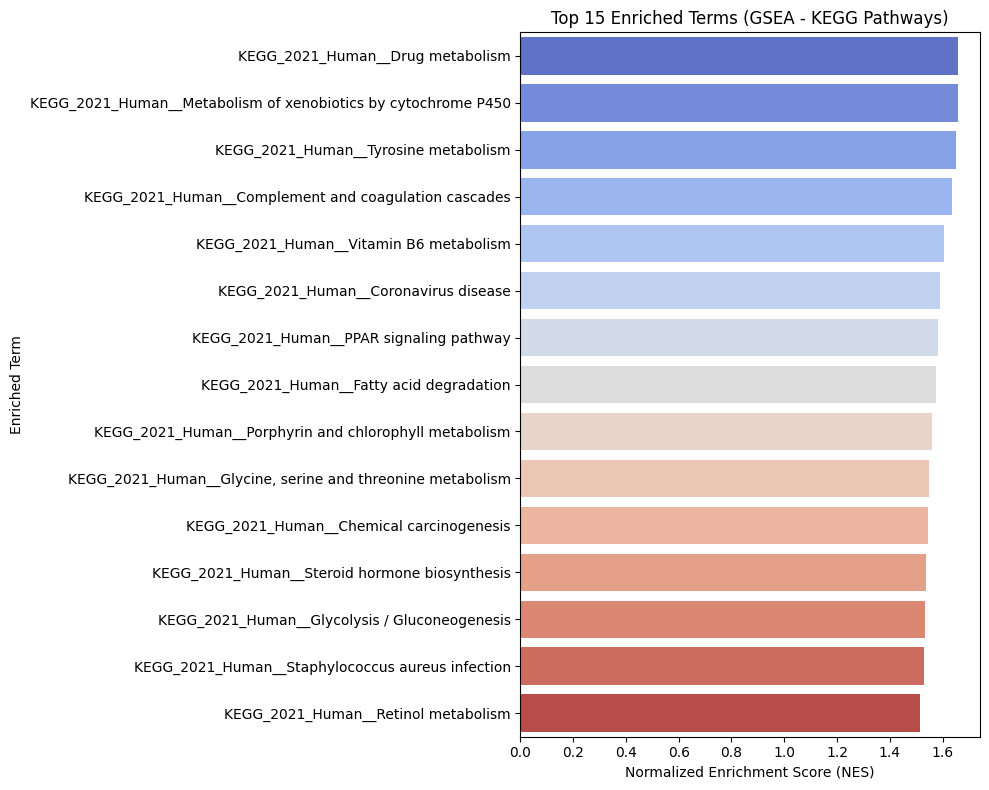

No GSEA results to plot for: GO Biological Process


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gsea_results(gsea_df, title, num_terms=15):
    if gsea_df.empty:
        print(f"No GSEA results to plot for: {title}")
        return

    # Filter for significant results and sort by NES (Normalized Enrichment Score)
    plot_df = gsea_df[gsea_df['FDR q-val'] < 0.05].sort_values(by='NES', ascending=False).head(num_terms).copy()

    if plot_df.empty:
        print(f"No significant GSEA terms to plot for: {title}")
        return

    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='NES',
        y='Term',
        data=plot_df,
        palette='coolwarm',
        orient='h'
    )
    plt.title(f'Top {num_terms} Enriched Terms (GSEA - {title})')
    plt.xlabel('Normalized Enrichment Score (NES)')
    plt.ylabel('Enriched Term')
    plt.tight_layout()
    plt.show()

# Plot GSEA results for KEGG pathways
kegg_results = GSEA_RESULTS.res2d[GSEA_RESULTS.res2d['Term'].str.contains('KEGG_2021_Human')]
plot_gsea_results(kegg_results, 'KEGG Pathways')

# Plot GSEA results for GO Biological Process terms
# Note: GSEApy reported 'GO_BP_2021' as unsupported, so this plot might be empty.
gobp_results = GSEA_RESULTS.res2d[GSEA_RESULTS.res2d['Term'].str.contains('GO_BP')]
plot_gsea_results(gobp_results, 'GO Biological Process')

### Subtask: Visualize Updated GSEA Results

Now, we will visualize the top enriched pathways from the updated GSEA results using bar plots, reflecting the successful analysis with a supported GO Biological Process gene set.

/tmp/ipykernel_22208/1619165411.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


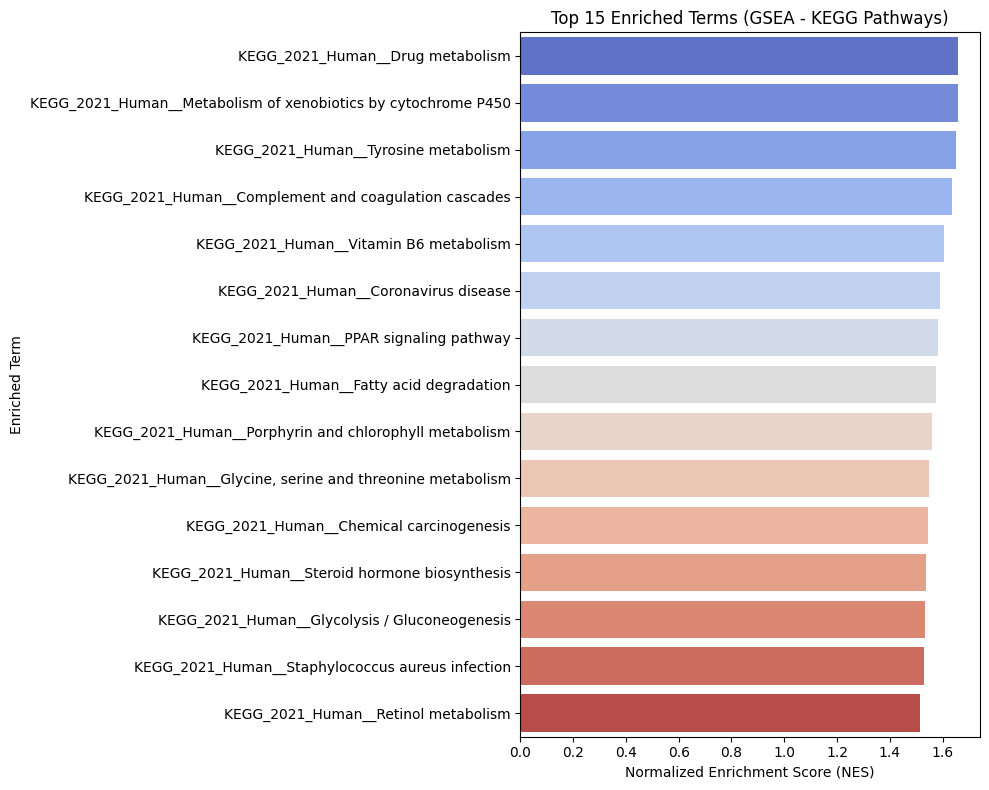

/tmp/ipykernel_22208/1619165411.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


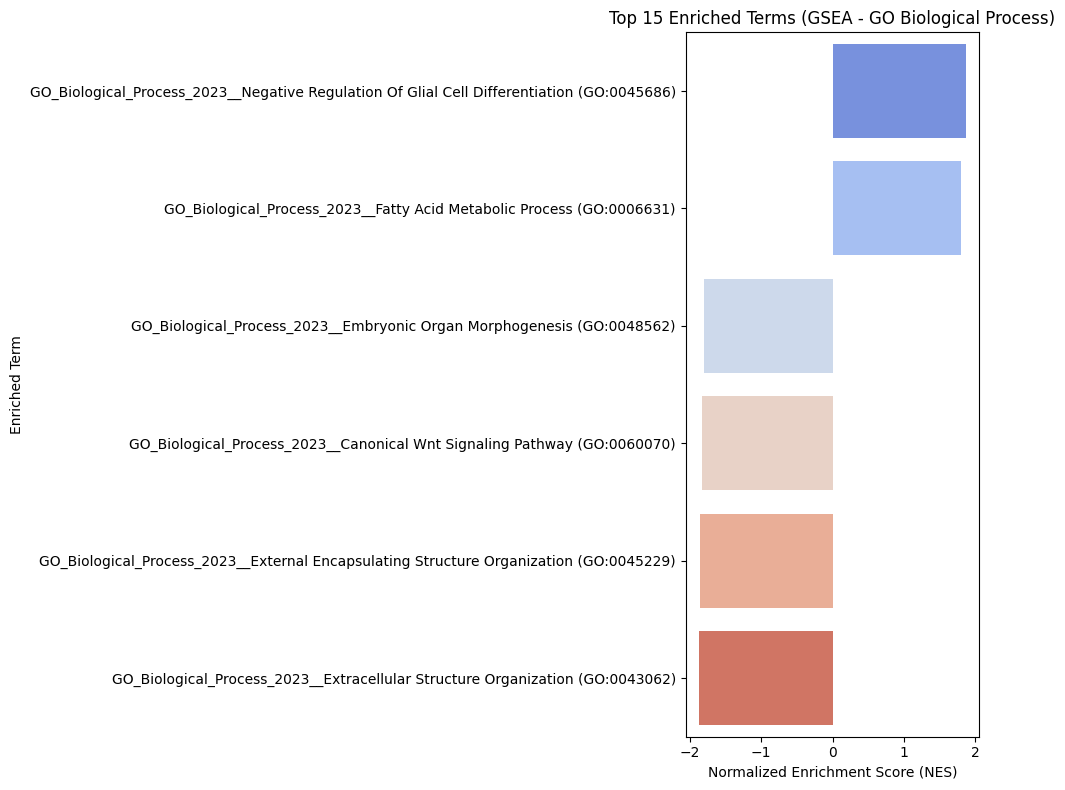

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_gsea_results(gsea_df, title, num_terms=15):
    if gsea_df.empty:
        print(f"No GSEA results to plot for: {title}")
        return

    # Filter for significant results and sort by NES (Normalized Enrichment Score)
    plot_df = gsea_df[gsea_df['FDR q-val'] < 0.05].sort_values(by='NES', ascending=False).head(num_terms).copy()

    if plot_df.empty:
        print(f"No significant GSEA terms to plot for: {title}")
        return

    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='NES',
        y='Term',
        data=plot_df,
        palette='coolwarm',
        orient='h'
    )
    plt.title(f'Top {num_terms} Enriched Terms (GSEA - {title})')
    plt.xlabel('Normalized Enrichment Score (NES)')
    plt.ylabel('Enriched Term')
    plt.tight_layout()
    plt.show()

# Plot GSEA results for KEGG pathways (using updated results)
kegg_results = GSEA_RESULTS.res2d[GSEA_RESULTS.res2d['Term'].str.contains('KEGG_2021_Human')]
plot_gsea_results(kegg_results, 'KEGG Pathways')

# Plot GSEA results for GO Biological Process terms (using updated results)
gobp_results = GSEA_RESULTS.res2d[GSEA_RESULTS.res2d['Term'].str.contains('GO_Biological_Process_2023')]
plot_gsea_results(gobp_results, 'GO Biological Process')

### Comparison of KEGG Pathways: ORA vs. GSEA

In [49]:
# Filter ORA results for KEGG pathways from ALL_DEGS_ENRICHMENT_RESULTS
ora_kegg_results = ALL_DEGS_ENRICHMENT_RESULTS[ALL_DEGS_ENRICHMENT_RESULTS['source'] == 'KEGG'].sort_values(by='p_value', ascending=True)

print("Top 10 KEGG pathways from ORA (All DEGs):")
display(ora_kegg_results.head(10))

print("\nTop 10 KEGG pathways from GSEA (preranked):")
display(kegg_results.sort_values(by='FDR q-val', ascending=True).head(10))

Top 10 KEGG pathways from ORA (All DEGs):


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
2,KEGG,KEGG:04610,Complement and coagulation cascades,3.350310e-52,True,Complement and coagulation cascades,86,382,55,8716,0.143979,0.639535,query_1,[KEGG:00000],"[CFHR2, CPB2, C9, C8B, C8A, MBL2, F9, PLG, F2,...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
82,KEGG,KEGG:00982,Drug metabolism - cytochrome P450,3.099870e-16,True,Drug metabolism - cytochrome P450,69,382,26,8716,0.068063,0.376812,query_1,[KEGG:00000],"[UGT2B4, ADH1A, UGT1A4, CYP2C8, UGT1A9, CYP2E1...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
84,KEGG,KEGG:01100,Metabolic pathways,4.514754e-16,True,Metabolic pathways,1564,382,138,8716,0.361257,0.088235,query_1,[KEGG:00000],"[UGT2B4, ARG1, FTCD, HAO1, CYP8B1, ADH1A, ACSM...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
97,KEGG,KEGG:00980,Metabolism of xenobiotics by cytochrome P450,3.504016e-15,True,Metabolism of xenobiotics by cytochrome P450,75,382,26,8716,0.068063,0.346667,query_1,[KEGG:00000],"[UGT2B4, ADH1A, UGT1A4, SULT2A1, UGT1A9, CYP2E...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
105,KEGG,KEGG:00830,Retinol metabolism,3.753634e-14,True,Retinol metabolism,68,382,24,8716,0.062827,0.352941,query_1,[KEGG:00000],"[UGT2B4, ADH1A, UGT1A4, CYP2C8, UGT1A9, RDH16,...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
121,KEGG,KEGG:04976,Bile secretion,5.490887e-13,True,Bile secretion,90,382,26,8716,0.068063,0.288889,query_1,[KEGG:00000],"[UGT2B4, SLC22A7, SLCO1B1, UGT1A4, SULT2A1, SL...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
136,KEGG,KEGG:05204,Chemical carcinogenesis - DNA adducts,5.384546e-12,True,Chemical carcinogenesis - DNA adducts,68,382,22,8716,0.057592,0.323529,query_1,[KEGG:00000],"[UGT2B4, UGT1A4, SULT2A1, CYP2C8, UGT1A9, CYP2...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
142,KEGG,KEGG:04979,Cholesterol metabolism,2.402928e-11,True,Cholesterol metabolism,52,382,19,8716,0.049738,0.365385,query_1,[KEGG:00000],"[APOB, ANGPTL3, LIPC, APOA2, APOC3, APOA1, APO...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
169,KEGG,KEGG:00140,Steroid hormone biosynthesis,3.155761e-10,True,Steroid hormone biosynthesis,66,382,20,8716,0.052356,0.303030,query_1,[KEGG:00000],"[UGT2B4, UGT1A4, UGT1A9, CYP2E1, AKR1D1, CYP3A...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
187,KEGG,KEGG:00260,"Glycine, serine and threonine metabolism",3.667035e-09,True,"Glycine, serine and threonine metabolism",39,382,15,8716,0.039267,0.384615,query_1,[KEGG:00000],"[AGXT2, AGXT, BHMT, GATM, DMGDH, GAMT, SARDH, ...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."



Top 10 KEGG pathways from GSEA (preranked):


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
2,prerank,KEGG_2021_Human__IL-17 signaling pathway,-0.77544,-1.85875,0.01,0.010000,0.01,22/92,7.04%,CCL11;MMP3;MMP1;CSF3;LCN2;MMP13;IL17B;MUC5B;CX...
7,prerank,KEGG_2021_Human__Pathways of neurodegeneration,-0.585951,-1.788716,0.01,0.010000,0.01,96/443,15.08%,WNT5A;WNT2B;ATP2A3;PRPH;NOS2;TUBAL3;COX6B2;WNT...
73,prerank,KEGG_2021_Human__Drug metabolism,0.948438,1.659094,0.01,0.010000,0.01,29/107,1.63%,CYP2E1;ADH1A;UGT2B4;CYP2C8;ADH4;UGT1A4;CYP3A4;...
74,prerank,KEGG_2021_Human__Metabolism of xenobiotics by ...,0.952244,1.658487,0.01,0.010000,0.01,29/75,2.17%,CYP2E1;ADH1A;UGT2B4;SULT2A1;ADH4;UGT1A4;CYP3A4...
100,prerank,KEGG_2021_Human__Complement and coagulation ca...,0.942993,1.637644,0.01,0.010000,0.02,48/85,1.54%,FGG;SERPINC1;C9;PLG;FGA;FGB;VTN;F2;CFHR2;C8B;C...
83,prerank,KEGG_2021_Human__Tyrosine metabolism,0.946987,1.649508,0.01,0.010000,0.01,11/36,1.65%,HPD;ADH1A;ADH4;TAT;AOX1;ADH1B;MAOB;DBH;FAH;ADH...
166,prerank,KEGG_2021_Human__Coronavirus disease,0.854872,1.591861,0.01,0.012485,0.09,21/226,1.85%,FGG;C9;FGA;FGB;F2;C8B;C8A;C6;MASP2;MBL2;C8G;F1...
176,prerank,KEGG_2021_Human__PPAR signaling pathway,0.901588,1.58429,0.01,0.012841,0.11,23/74,2.92%,APOC3;APOA2;APOA1;APOA5;CYP8B1;SLC27A5;PLIN2;A...
196,prerank,KEGG_2021_Human__Fatty acid degradation,0.939515,1.577002,0.01,0.013109,0.13,13/43,3.22%,ADH1A;ADH4;ADH1B;ACADL;ACSL1;ADH6;ACADSB;ALDH2...
27,prerank,KEGG_2021_Human__Asthma,-0.849344,-1.721118,0.01,0.014011,0.05,2/30,1.40%,CCL11;MS4A2


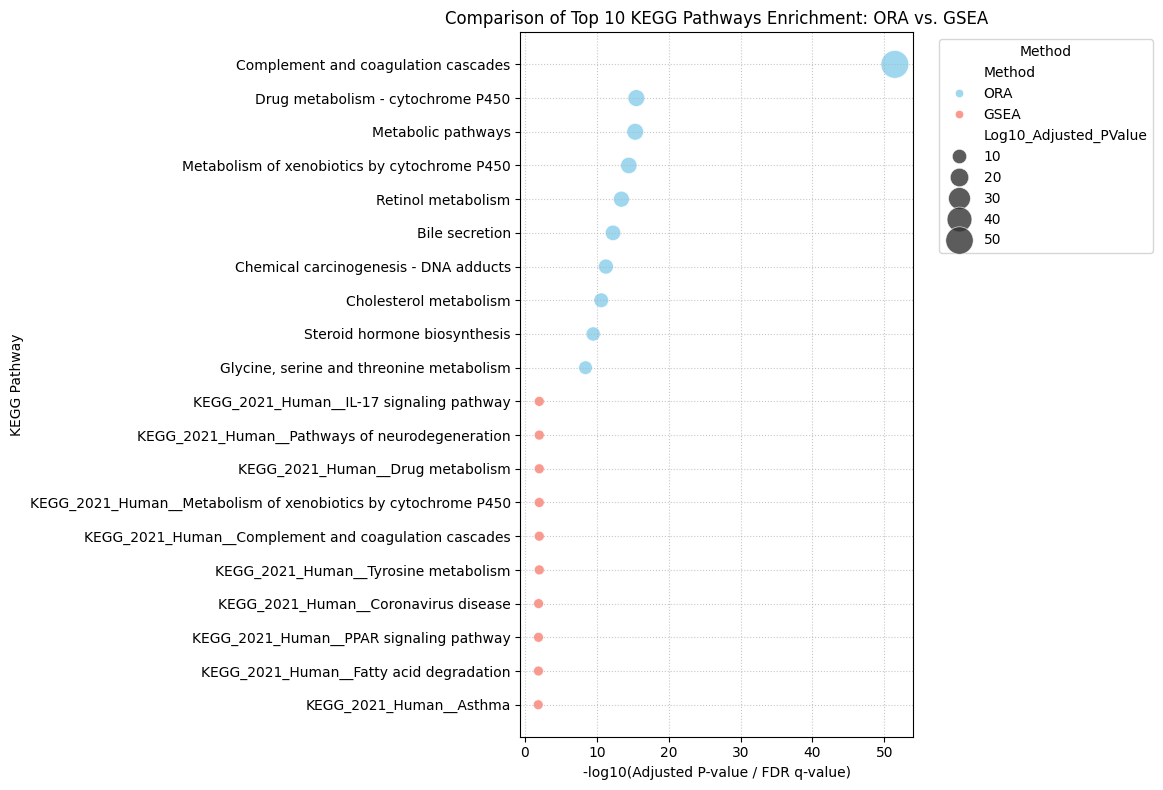

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the number of top terms to compare from each method
NUM_TOP_TERMS = 10

# --- Prepare ORA KEGG results ---
# Filter ORA results for KEGG pathways and select top N by p_value
ora_kegg_plot_df = ora_kegg_results.head(NUM_TOP_TERMS).copy()
ora_kegg_plot_df['Log10_Adjusted_PValue'] = -np.log10(ora_kegg_plot_df['p_value'])
ora_kegg_plot_df['Method'] = 'ORA'
ora_kegg_plot_df = ora_kegg_plot_df[['name', 'Log10_Adjusted_PValue', 'Method']]
ora_kegg_plot_df.rename(columns={'name': 'Pathway'}, inplace=True)

# --- Prepare GSEA KEGG results ---
# Filter GSEA results for KEGG pathways and select top N by FDR q-val
gsea_kegg_plot_df = kegg_results.sort_values(by='FDR q-val', ascending=True).head(NUM_TOP_TERMS).copy()
gsea_kegg_plot_df['Log10_Adjusted_PValue'] = -np.log10(gsea_kegg_plot_df['FDR q-val'])
gsea_kegg_plot_df['Method'] = 'GSEA'
gsea_kegg_plot_df = gsea_kegg_plot_df[['Term', 'Log10_Adjusted_PValue', 'Method']]
gsea_kegg_plot_df.rename(columns={'Term': 'Pathway'}, inplace=True)

# Combine the results for plotting
combined_kegg_results = pd.concat([ora_kegg_plot_df, gsea_kegg_plot_df])

# Ensure Pathway column is categorical for consistent ordering in plot
# Get all unique pathways and create a categorical type
all_pathways = combined_kegg_results['Pathway'].unique()
combined_kegg_results['Pathway'] = pd.Categorical(combined_kegg_results['Pathway'], categories=all_pathways, ordered=True)

# Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=combined_kegg_results,
    x='Log10_Adjusted_PValue',
    y='Pathway',
    hue='Method',
    size='Log10_Adjusted_PValue', # Use significance for dot size
    sizes=(50, 400), # Range of dot sizes
    palette={'ORA': 'skyblue', 'GSEA': 'salmon'},
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

plt.title(f'Comparison of Top {NUM_TOP_TERMS} KEGG Pathways Enrichment: ORA vs. GSEA')
plt.xlabel('-log10(Adjusted P-value / FDR q-value)')
plt.ylabel('KEGG Pathway')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Export GSEA KEGG Results to Excel

In [48]:
output_kegg_file = 'gsea_kegg_results.xlsx'
kegg_results.to_excel(output_kegg_file, index=False)
print(f"Successfully saved GSEA KEGG results to '{output_kegg_file}'.")

Successfully saved GSEA KEGG results to 'gsea_kegg_results.xlsx'.
